# Прогнозирование спроса в рознице — EDA датасета M5 (Walmart)

**Контекст проекта**

**Проблема**

Сезонность, акции и нулевой спрос приводят к ошибкам прогноза, а ошибки прогноза превращаются в:
- out-of-stock (упущенная выручка);
- мёртвый склад (расходы на хранение товаров и списания). 

Цель — построить ML-модель прогноза спроса, которая обоснованно превосходит baseline.

**Цель EDA**

Сформировать представление о данных перед созданием модели:
- описать состав данных;
- оценить качество данных;
- оценить иерархию рядов;
- оценить распределение нулевого спроса;
- выделить сезонности и эффекты ковариат.

**Основные задачи**
1. Загрузить и описать данные (таблицы sales / calendar / sell_prices).
2. Оценить качество данных и сделать при не необходимости их обработку.
2. Привести данные к формату дата × магазин × товар × количество.
3. Провести базовый EDA с выводами для создания модели.
5. Описать алгоритм формирования выборки.

In [1]:
!pip install pandas numpy matplotlib seaborn statsmodels scikit-learn optuna lightgbm statsforecast neuralforecast -q


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from typing import List, Optional, Dict
from pathlib import Path
import time
import joblib
import os
import gc

from tqdm.auto import tqdm

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import StandardScaler

import optuna

from sklearn.preprocessing import OneHotEncoder
from scipy import sparse

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, AutoARIMA, CrostonOptimized, TSB, IMAPA
from neuralforecast import NeuralForecast
from neuralforecast.models import DeepAR
from neuralforecast.losses.pytorch import DistributionLoss

from sklearn.metrics import mean_absolute_error, mean_squared_error

from scipy.optimize import minimize

import torch

### Настройки

In [3]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

### Переменные

In [5]:
RANDOM_STATE = 42

### Функции

In [6]:
def decompose_time_series(data, period, model='additive'):
    """Сезонная декомпозиция ряда. Возвращает объект DecomposeResult или None при ошибке."""
    try:
        decomposition = seasonal_decompose(data, model=model, period=period)
        return decomposition
    except Exception as e:
        print(f"Ошибка декомпозиции с периодом {period}: {e}")
        return None

In [7]:
def plot_weekly_seasonality(decomposition):
    """Средняя сезонная компонента по дням недели."""
    if decomposition is None:
        return
    seasonal = decomposition.seasonal.dropna()
    day_of_week = seasonal.index.dayofweek
    seasonal_by_dow = seasonal.groupby(day_of_week).mean()
    days_rus = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

    plt.figure(figsize=(10, 4))
    plt.bar(days_rus, seasonal_by_dow.values, color='skyblue', edgecolor='black')
    plt.xlabel('День недели', fontsize=12)
    plt.ylabel('Средняя недельная сезонная компонента', fontsize=12)
    plt.title('Недельная сезонность: среднее отклонение по дням недели', fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
def plot_monthly_day_seasonality(decomposition):
    """Внутримесячная сезонность по дням месяца."""
    if decomposition is None:
        return
    residual = decomposition.resid.dropna()
    day_of_month = residual.index.day
    seasonal_by_dom = residual.groupby(day_of_month).mean()

    plt.figure(figsize=(12, 5))
    plt.bar(seasonal_by_dom.index, seasonal_by_dom.values,
            color='mediumseagreen', edgecolor='black')
    plt.xlabel('День месяца', fontsize=12)
    plt.ylabel('Средняя остаточная компонента', fontsize=12)
    plt.title('Внутримесячная сезонность: среднее отклонение по дням месяца', fontsize=14)
    plt.xticks(range(1, 32, 2))
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [9]:
def plot_monthly_trend(decomposition):
    """Среднемесячный тренд."""
    if decomposition is None:
        return
    trend = decomposition.trend.dropna()
    month_of_year = trend.index.month
    trend_by_month = trend.groupby(month_of_year).mean()

    plt.figure(figsize=(10, 4))
    plt.plot(trend_by_month.index, trend_by_month.values,
             marker='o', linestyle='-', color='darkgreen')
    plt.xlabel('Месяц', fontsize=12)
    plt.ylabel('Средний тренд', fontsize=12)
    plt.title('Среднемесячный тренд продаж', fontsize=14)
    plt.xticks(range(1, 13), ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                              'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек'])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1. Подготовка

### 1.1 Источник и состав данных

**Источник.** M5 Forecasting Competition (Kaggle, 2020), организатор — University of Nicosia совместно с Walmart. 

Публичная ссылка на оригинальный датасет: https://www.kaggle.com/competitions/m5-forecasting-accuracy/data

### 1.2 Загрузка данных

In [10]:
DATA_DIR = Path('./m5-forecasting-accuracy')

In [11]:
sales = pd.read_csv(DATA_DIR / 'sales_train_evaluation.csv', sep=',')

In [12]:
print(f'Sales: {sales.shape}')

Sales: (30490, 1947)


In [13]:
calendar = pd.read_csv(DATA_DIR / 'calendar.csv', parse_dates=['date'], sep=',')

In [14]:
print(f'Calendar: {calendar.shape}')

Calendar: (1969, 14)


In [15]:
prices = pd.read_csv(DATA_DIR / 'sell_prices.csv', sep=',')

In [16]:
print(f'Prices: {prices.shape}')

Prices: (6841121, 4)


### 1.3 Описание данных

In [17]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


In [18]:
calendar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1969 non-null   datetime64[ns]
 1   wm_yr_wk      1969 non-null   int64         
 2   weekday       1969 non-null   object        
 3   wday          1969 non-null   int64         
 4   month         1969 non-null   int64         
 5   year          1969 non-null   int64         
 6   d             1969 non-null   object        
 7   event_name_1  162 non-null    object        
 8   event_type_1  162 non-null    object        
 9   event_name_2  5 non-null      object        
 10  event_type_2  5 non-null      object        
 11  snap_CA       1969 non-null   int64         
 12  snap_TX       1969 non-null   int64         
 13  snap_WI       1969 non-null   int64         
dtypes: datetime64[ns](1), int64(7), object(6)
memory usage: 215.5+ KB


In [19]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


### 1.4 Первые записи

In [20]:
sales.iloc[:, :20].head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [21]:
calendar.head(5)

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [22]:
prices.head(5)

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


### 1.5 Объединение данных

#### Приведение данных о продажах к формату: дата × магазин × товар × количество

Wide-формат (магазин × товар по строкам, а дни по столбцам) удобен для хранения, но неудобен для анализа данных и создания моделей.

Нужен long-формат: одна строка = одно наблюдение `(дата × магазин × товар)`. 

Разворачиваем данные в естественный формат.

In [23]:
id_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
d_cols  = [c for c in sales.columns if c.startswith('d_')]

sales_long = sales[id_cols + d_cols].melt(
    id_vars=id_cols,
    var_name='d',
    value_name='sales'
)

In [24]:
sales_long.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 8 columns):
 #   Column    Non-Null Count     Dtype 
---  ------    --------------     ----- 
 0   id        59181090 non-null  object
 1   item_id   59181090 non-null  object
 2   dept_id   59181090 non-null  object
 3   cat_id    59181090 non-null  object
 4   store_id  59181090 non-null  object
 5   state_id  59181090 non-null  object
 6   d         59181090 non-null  object
 7   sales     59181090 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 3.5+ GB


#### Данные о продажах + Календарь

In [25]:
calendar_cols = ['date', 'd', 'wm_yr_wk', 'wday', 'month', 'year',
                 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2', 'snap_CA', 'snap_TX', 'snap_WI']

sales_long = sales_long.merge(calendar[calendar_cols], on='d', how='left', validate='many_to_one')

In [26]:
sales_long['state_id'].value_counts()

state_id
CA    23672436
TX    17754327
WI    17754327
Name: count, dtype: int64

In [27]:
# SNAP (программа продовольственной помощи в США) по штату клиента
sales_long['snap'] = np.where(sales_long['state_id'] == 'CA', sales_long['snap_CA'],
                       np.where(sales_long['state_id'] == 'TX', sales_long['snap_TX'],
                                sales_long['snap_WI'])).astype(int)

sales_long = sales_long.drop(columns=['snap_CA', 'snap_TX', 'snap_WI'])

In [28]:
sales_long['has_event'] = (
    (sales_long['event_name_1'].notna() & (sales_long['event_name_1'] != '')) |
    (sales_long['event_name_2'].notna() & (sales_long['event_name_2'] != ''))
).astype(int)

#### Данные о продажах + Календарь + Данные о ценах

In [29]:
sales_long = sales_long.merge(prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left', validate='many_to_one')

#### Итоговый набор данных для анализа

In [30]:
print(f'Размер данных: {sales_long.shape}')
print(f'Период:     {sales_long["date"].min().date()} .. {sales_long["date"].max().date()}')
print(f'Уникальное кол-во товаров:  {sales_long["item_id"].nunique()}')
print(f'Уникальное кол-во магазинов: {sales_long["store_id"].nunique()}')
print(f'Уникальное кол-во временных рядов: {sales_long["id"].nunique()}')

Размер данных: (59181090, 20)
Период:     2011-01-29 .. 2016-05-22
Уникальное кол-во товаров:  3049
Уникальное кол-во магазинов: 10
Уникальное кол-во временных рядов: 30490


In [31]:
sales_long['cat_id'].value_counts()

cat_id
FOODS        27892170
HOUSEHOLD    20322270
HOBBIES      10966650
Name: count, dtype: int64

In [32]:
sales_long.groupby(['cat_id', 'dept_id'])['id'].count()

cat_id     dept_id    
FOODS      FOODS_1         4192560
           FOODS_2         7725180
           FOODS_3        15974430
HOBBIES    HOBBIES_1       8074560
           HOBBIES_2       2892090
HOUSEHOLD  HOUSEHOLD_1    10326120
           HOUSEHOLD_2     9996150
Name: id, dtype: int64

In [33]:
sales_long.groupby(['state_id', 'store_id'])['id'].count()

state_id  store_id
CA        CA_1        5918109
          CA_2        5918109
          CA_3        5918109
          CA_4        5918109
TX        TX_1        5918109
          TX_2        5918109
          TX_3        5918109
WI        WI_1        5918109
          WI_2        5918109
          WI_3        5918109
Name: id, dtype: int64

In [34]:
sales_long.head(5)

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap,has_event,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN


**Выводы:**

**Состав данных.**:

| Файл | Что содержит |
|---|---|
| `sales_train_evaluation.csv` | Матрица продаж в wide-формате: 30 490 строк (магазин x товар) × 1 941 столбец дней (d_1..d_1941) |
| `calendar.csv` | Календарь с праздниками, событиями и SNAP-флагами (1 941 строка) |
| `sell_prices.csv` | Еженедельные цены по комбинации магазин × товар × неделя |

**Иерархия данных в M5:** 12 уровней агрегации — от отдельной комбинации товар × магазин до суммарных продаж Walmart. 

**Базовые сущности:**
- 3 категории: FOODS, HOBBIES, HOUSEHOLD
- 7 отделов внутри категорий (FOODS_1, FOODS_2, FOODS_3, HOBBIES_1, HOBBIES_2, HOUSEHOLD_1, HOUSEHOLD_2)
- 3 049 уникальных товаров
- 10 магазинов в 3 штатах (CA: 4, TX: 3, WI: 3)
- Итого 30 490 = 3 049 × 10 рядов на нижнем уровне

**Период наблюдений:** 
- с 29 января 2011 по 19 июня 2016 (1 941 день).

## 2. Базовый EDA

### 2.1 Структура иерархии и статистика по уровням

Иерархия M5 — главная особенность датасета.

Один и тот же спрос можно прогнозировать на разных уровнях: в целом по штату, по категории, по магазину или на уровне отдельного SKU.

In [35]:
# Базовая статистика на разных уровнях
levels = {
    'Walmart': sales_long.groupby('date')['sales'].sum(),
    'По штату': sales_long.groupby(['date', 'state_id'])['sales'].sum().unstack(),
    'По категории': sales_long.groupby(['date', 'cat_id'])['sales'].sum().unstack(),
    'По магазину': sales_long.groupby(['date', 'store_id'])['sales'].sum().unstack(),
}

In [36]:
print('Размер ряда на разных уровнях агрегации:')
for name, data in levels.items():
    if isinstance(data, pd.Series):
        print(f'  {name:20s}: 1 ряд, в среднем {data.mean():.0f} ед./день, CV={data.std()/data.mean():.2f}')
    else:
        cvs = (data.std() / data.mean()).values
        print(f'  {name:20s}: {data.shape[1]} рядов, '
              f'CV среднее={cvs.mean():.2f}, CV максимальное={cvs.max():.2f}')

Размер ряда на разных уровнях агрегации:
  Walmart             : 1 ряд, в среднем 34481 ед./день, CV=0.22
  По штату            : 3 рядов, CV среднее=0.23, CV максимальное=0.27
  По категории        : 3 рядов, CV среднее=0.24, CV максимальное=0.29
  По магазину         : 10 рядов, CV среднее=0.26, CV максимальное=0.38


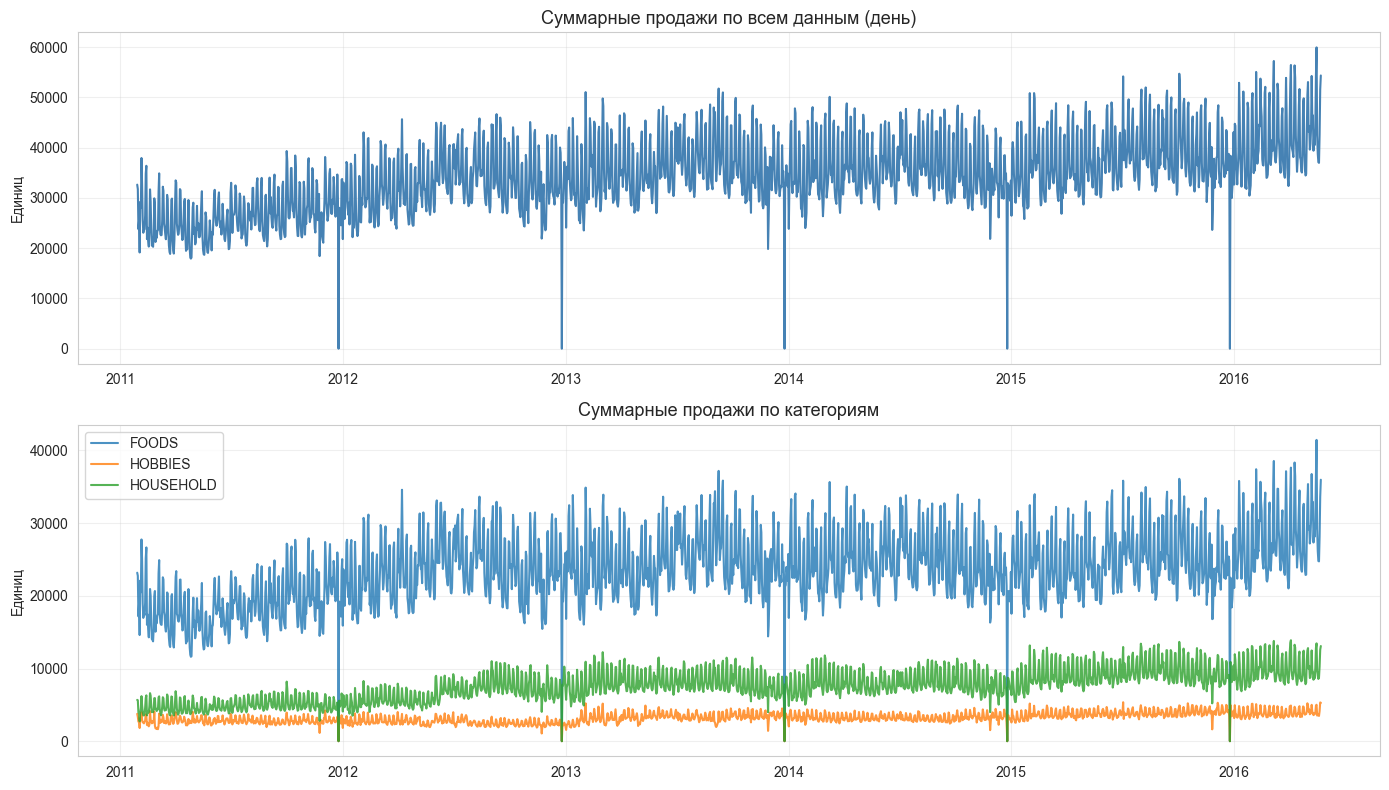

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

total = sales_long.groupby('date')['sales'].sum()
axes[0].plot(total.index, total.values, color='steelblue')
axes[0].set_title('Суммарные продажи по всем данным (день)', fontsize=13)
axes[0].set_ylabel('Единиц')
axes[0].grid(True, alpha=0.3)

by_cat = sales_long.groupby(['date', 'cat_id'])['sales'].sum().unstack()
for col in by_cat.columns:
    axes[1].plot(by_cat.index, by_cat[col].values, label=col, alpha=0.8)
axes[1].set_title('Суммарные продажи по категориям', fontsize=13)
axes[1].set_ylabel('Единиц')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы:** 

Коэффициент вариации (CV = std/mean) сильно увеличивается по мере углубления по иерархии: верхние уровни более гладкие и сезонные, нижние хаотичнее с большой долей нулей.

### 2.2 Прерывистый спрос (intermittent demand)

In [38]:
zero_share_per_series = sales_long.groupby('id')['sales'].apply(lambda x: (x == 0).mean())

In [39]:
print(f'Доля нулей в данных в целом: {(sales_long["sales"] == 0).mean():.1%}')
print(f'\nРаспределение доли нулей по рядам:')
print(zero_share_per_series.describe().round(3))

Доля нулей в данных в целом: 68.0%

Распределение доли нулей по рядам:
count    30490.000
mean         0.680
std          0.223
min          0.002
25%          0.535
50%          0.733
75%          0.865
max          0.994
Name: sales, dtype: float64


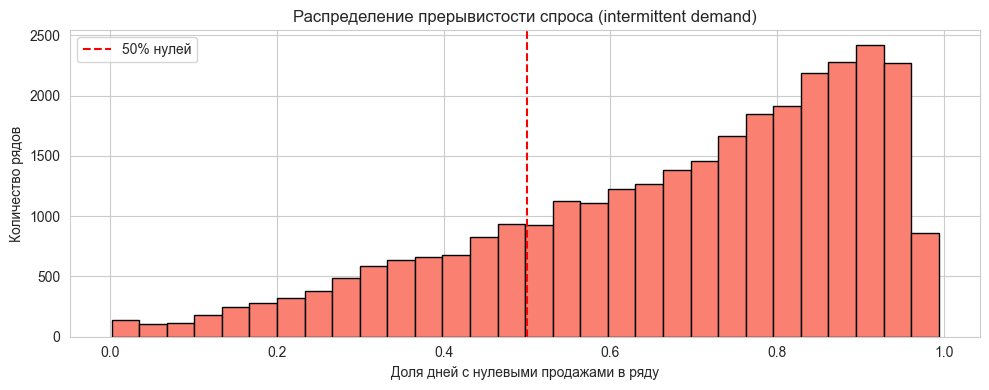

In [40]:
plt.figure(figsize=(10, 4))
plt.hist(zero_share_per_series, bins=30, color='salmon', edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--', label='50% нулей')
plt.xlabel('Доля дней с нулевыми продажами в ряду')
plt.ylabel('Количество рядов')
plt.title('Распределение прерывистости спроса (intermittent demand)')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
zero_by_cat = sales_long.groupby('cat_id')['sales'].apply(lambda x: (x == 0).mean()).sort_values()

In [42]:
print('Доля нулевых дней по категориям:')
for cat, share in zero_by_cat.items():
    print(f'  {cat:12s}: {share:.1%}')

Доля нулевых дней по категориям:
  FOODS       : 61.8%
  HOUSEHOLD   : 71.6%
  HOBBIES     : 77.1%


**Выводы:**

- Главная особенность данных в розничных продажах - значительная доля дней с нулевыми продажами на нижнем уровне (магазин × товар × день). По всему датасету доля нулей составляет **68%**.
- Прерывистость спроса распределена по рядам неравномерно: в среднем на ряд приходится **68% нулевых дней** (медиана **73%**). Уже на уровне нижнего квартиля (25% рядов) доля нулей превышает **53%**, а у четверти рядов (75-й перцентиль) — выше **86%**. Самый прерывистый ряд почти полностью состоит из нулей (**99.4%**), а самый плотный — практически без нулей (**0.2%**).
- Категория **HOBBIES имеет наибольшую долю нулей (77.1%)** — товары покупают редко; **FOODS — наименьшую (61.8%)** как повседневный спрос; HOUSEHOLD занимает промежуточное положение (**71.6%**).
- Такой разброс прерывистости означает, что единая модель должна одинаково хорошо работать и наболее «плотных» рядах FOODS, и на почти «нулевых» рядах HOBBIES.
- При создании модели должна быть использована метрика **RMSSE / WRMSSE**, как устойчивая к нулям.

### 2.3 Распределение целевой переменной

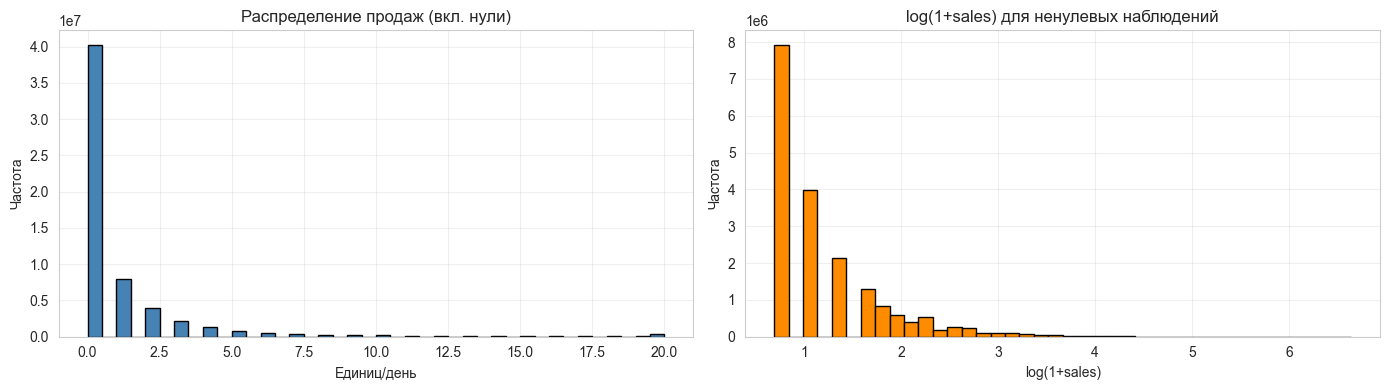

Среднее: 1.13
Медиана: 0.00
Максимум: 763
Асимметрия: 17.12


In [43]:
nonzero = sales_long.loc[sales_long['sales'] > 0, 'sales']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(sales_long['sales'].clip(upper=20), bins=40, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение продаж (вкл. нули)')
axes[0].set_xlabel('Единиц/день')
axes[0].set_ylabel('Частота')
axes[0].grid(alpha=0.3)

axes[1].hist(np.log1p(nonzero), bins=40, color='darkorange', edgecolor='black')
axes[1].set_title('log(1+sales) для ненулевых наблюдений')
axes[1].set_xlabel('log(1+sales)')
axes[1].set_ylabel('Частота')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Среднее: {sales_long["sales"].mean():.2f}')
print(f'Медиана: {sales_long["sales"].median():.2f}')
print(f'Максимум: {sales_long["sales"].max()}')
print(f'Асимметрия: {sales_long["sales"].skew():.2f}')

**Выводы:**

Сильно правоскошенное распределение с длинным хвостом.

- **Медиана равна нулю** (0) при среднем 1.13 — это означает, что более половины всех наблюдений нулевые, что согласуется с ранее выявленными 68% нулей. Среднее существенно выше медианы именно из-за редких крупных всплесков.
- **Асимметрия 17.12** — высокое значение. Это означает, что подавляющее большинство ненулевых продаж невелики (1–5 единиц), но редкие всплески уходят далеко вправо — вплоть до максимума **763 единицы в день** по одному товару в одном магазине. Такие всплески, вероятнее всего, соответствуют праздникам и промоакциям.

### 2.4 Сезонность (декомпозиция)

In [44]:
total_daily = sales_long.groupby('date')['sales'].sum()
total_daily = total_daily.asfreq('D')

In [45]:
decomp_weekly = decompose_time_series(total_daily, period=7)
decomp_yearly = decompose_time_series(total_daily, period=365)

#### Недельная сезонность

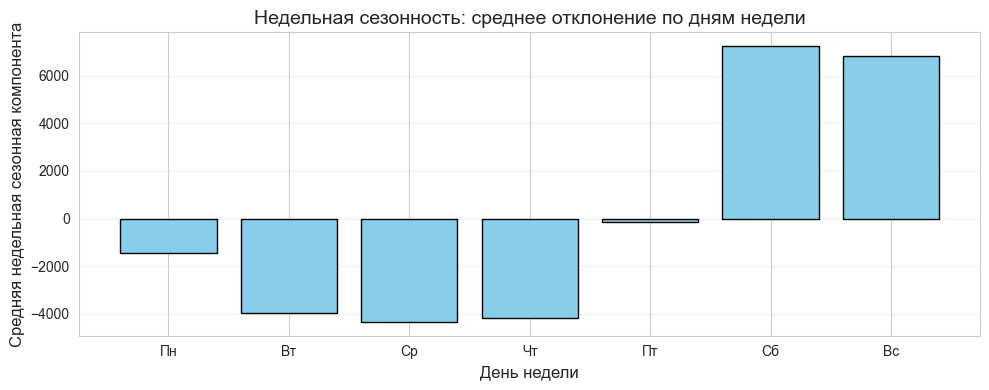

In [46]:
plot_weekly_seasonality(decomp_weekly)

#### Внутримесячная сезонность

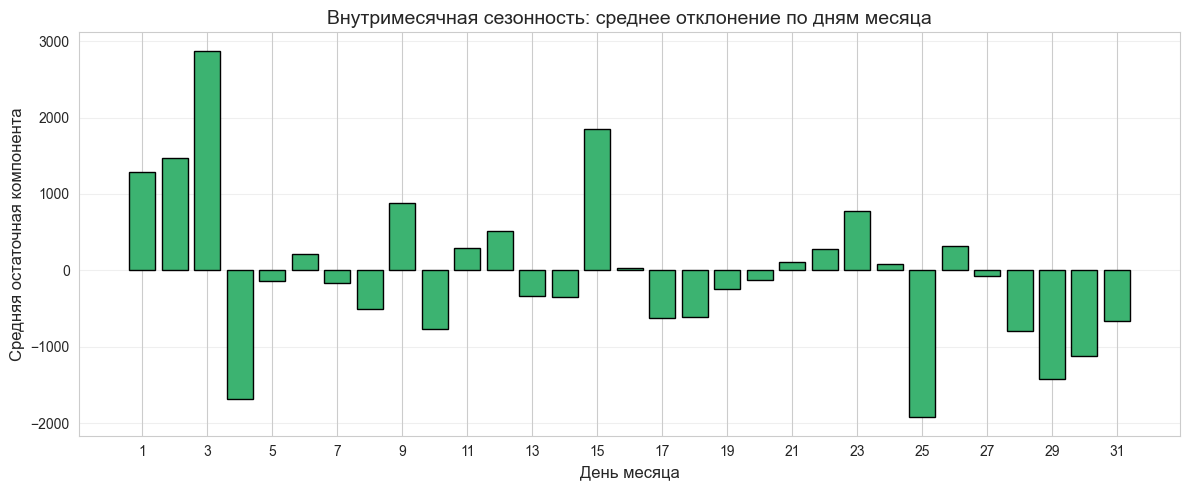

In [47]:
plot_monthly_day_seasonality(decomp_weekly)

#### Среднемесячный тренд

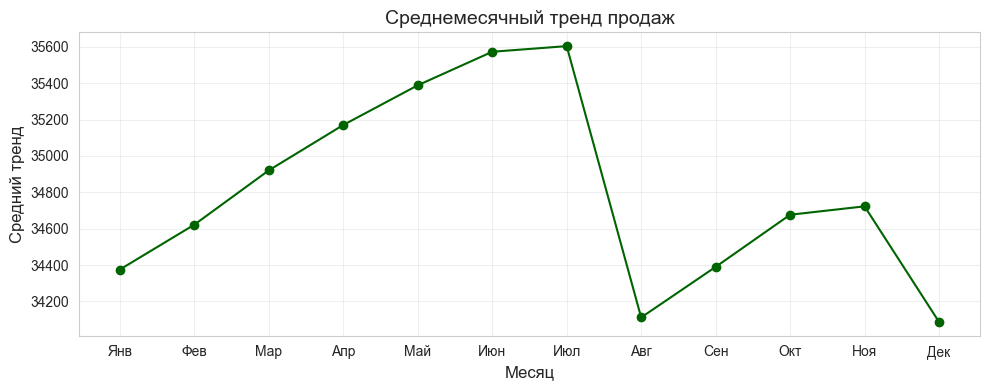

In [48]:
plot_monthly_trend(decomp_yearly)

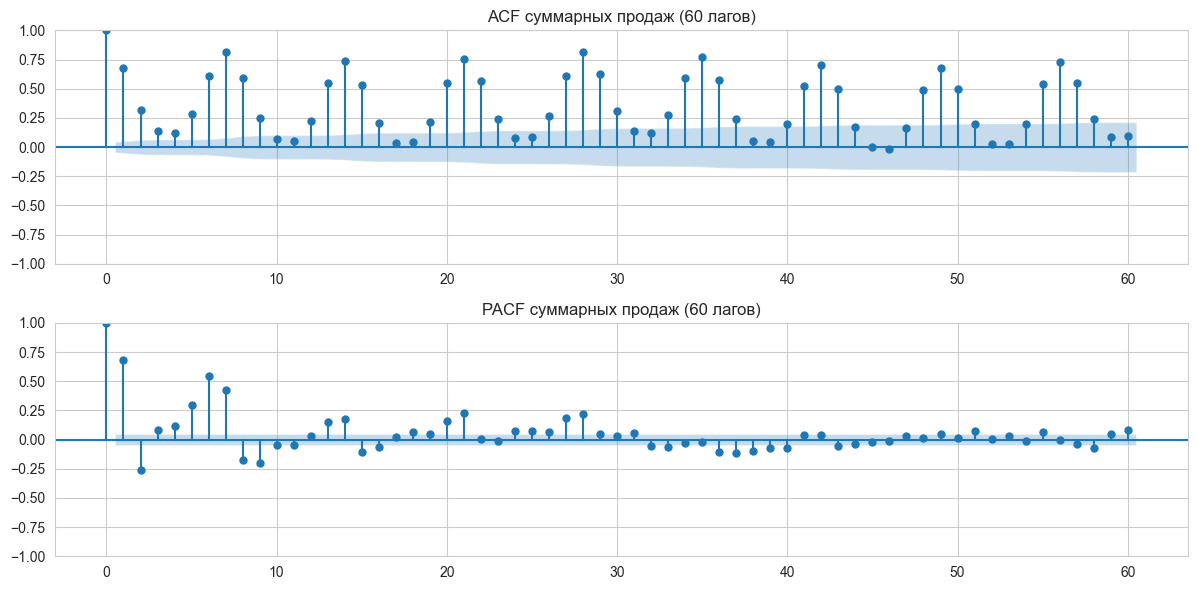

In [49]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
plot_acf(total_daily.dropna(), lags=60, ax=axes[0])
axes[0].set_title('ACF суммарных продаж (60 лагов)')
plot_pacf(total_daily.dropna(), lags=60, ax=axes[1])
axes[1].set_title('PACF суммарных продаж (60 лагов)')
plt.tight_layout()
plt.show()

**Выводы:**

- **Недельная сезонность ярко выражена** — резкий рост в выходные: суббота и воскресенье значительно выше среднего, тогда как значения в будни уходят в минус, причем значения минимальны в среду и четверг. В пятница значение практически равно 0. Это нужно отразить как лаги 7, 14, 21 и признак `dayofweek`.

- **Внутримесячная сезонность** носит выраженный двухпиковый характер: первый пик приходится на 1–3 числа месяца, второй — около 15-го числа. Оба пика примерно совпадают с типичными датами выплат SNAP-пособий в США. Концу месяца соответствуют отрицательные значения (25–31 числа). Это подтверждает важность признака `snap` и `day_of_month`.

- **Среднемесячный тренд** демонстрирует два разнонаправленных периода: устойчивый рост с января по июль и резкий спад в августе, после чего следует частичное восстановление в октябре–ноябре с новым провалом в декабре. Летний пик, вероятно, объясняется ростом продаж напитков и сезонных товаров, августовский провал — сезонным эффектом конца школьных каникул. Признак `month` или `weekofyear` нужно включать в модель.

- **ACF** показывает устойчивые значимые пики на лагах 1, 7, 14, 21, 28 и далее с периодом 7 — паттерн не затухает на протяжении всех 60 лагов, что подтверждает сильную и устойчивую недельную сезонность. **PACF** значим на лагах 1, 2, 7, 8 и частично 6, после чего быстро затухает — это говорит о том, что прямая авторегрессионная зависимость сосредоточена в пределах одной недели. Итог для feature engineering: используем лаги **{1, 2, 7, 8, 14, 28}** и rolling means размером **{7, 28}**.

### 2.5 Анализ ковариат

Ковариаты — внешние переменные, которые помогают модели объяснить спрос: цены, праздники, SNAP-флаги. Проверяем их влияние на продажи количественно.

#### Эффект SNAP-дней (только категория FOODS, для которой SNAP применим)

In [50]:
foods = sales_long[sales_long['cat_id'] == 'FOODS']
snap_effect = foods.groupby('snap')['sales'].agg(['mean', 'median', 'count'])
uplift = snap_effect.loc[1, 'mean'] / snap_effect.loc[0, 'mean'] - 1

In [51]:
print('Продажи FOODS в обычные дни vs SNAP-дни:')
print(snap_effect)
print(f'\nОтносительный прирост продаж в SNAP-дни по сравнению с обычными днями по среднему значению: {uplift:+.1%}')

Продажи FOODS в обычные дни vs SNAP-дни:
          mean  median     count
snap                            
0     1.557814     0.0  18695370
1     1.826562     0.0   9196800

Относительный прирост продаж в SNAP-дни по сравнению с обычными днями по среднему значению: +17.3%


#### Эффект праздников

In [52]:
event_effect = sales_long.groupby('has_event')['sales'].mean()

In [53]:
print('Продажи в обычные дни vs дни с праздниками:')
print(event_effect)
print(f'\nОтносительный прирост продаж в дни с праздниками по сравнению с обычными днями по среднему значению: {(event_effect[1]/event_effect[0]-1):+.1%}')

Продажи в обычные дни vs дни с праздниками:
has_event
0    1.135105
1    1.083303
Name: sales, dtype: float64

Относительный прирост продаж в дни с праздниками по сравнению с обычными днями по среднему значению: -4.6%


#### Корреляция продаж и цены (на уровне магазин x товар)

C:\Users\Константин\AppData\Local\Temp\ipykernel_50064\835207906.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = sample.groupby(pd.cut(sample['sell_price'], 30))['sales'].mean()
C:\Users\Константин\AppData\Local\Temp\ipykernel_50064\835207906.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  corrs = sales_long.dropna(subset=['sell_price']).groupby('cat_id').apply(


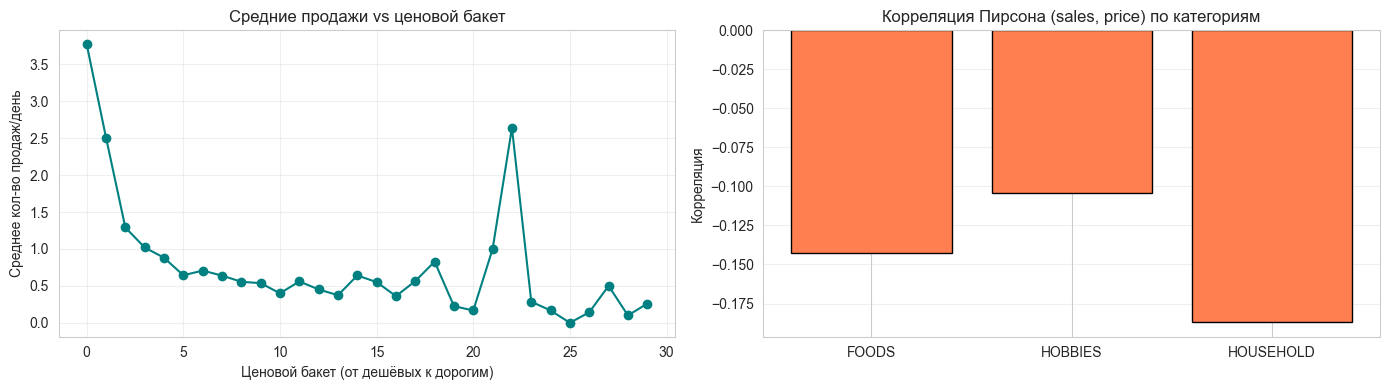

Корреляции по категориям:
cat_id
FOODS       -0.143
HOBBIES     -0.104
HOUSEHOLD   -0.187
dtype: float64


In [54]:
sample = sales_long.dropna(subset=['sell_price']).sample(min(50000, len(sales_long)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

agg = sample.groupby(pd.cut(sample['sell_price'], 30))['sales'].mean()
axes[0].plot(range(len(agg)), agg.values, marker='o', color='teal')
axes[0].set_title('Средние продажи vs ценовой бакет')
axes[0].set_xlabel('Ценовой бакет (от дешёвых к дорогим)')
axes[0].set_ylabel('Среднее кол-во продаж/день')
axes[0].grid(alpha=0.3)

corrs = sales_long.dropna(subset=['sell_price']).groupby('cat_id').apply(
    lambda d: d[['sales', 'sell_price']].corr().iloc[0, 1]
)
axes[1].bar(corrs.index, corrs.values, color='coral', edgecolor='black')
axes[1].set_title('Корреляция Пирсона (sales, price) по категориям')
axes[1].set_ylabel('Корреляция')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('Корреляции по категориям:')
print(corrs.round(3))

**Вывод:**

- **Эффект SNAP-дней для категории FOODS положительный (+17.3%)** — в дни социальных выплат среднее количество проданных единиц товара вырастает с 1.56 до 1.83. При этом медиана в обоих случаях остаётся нулевой, что отражает высокую долю нулевых продаж даже в SNAP-дни — эффект проявляется не в том, что товар начинают покупать все, а в том, что те, кто покупает, берут больше. Обязательно включаем `snap` как ковариату.

- **Праздничный эффект отрицательный (−4.6%)** — в дни с праздниками средние продажи немного ниже, чем в обычные дни (1.08 против 1.14). Это контринтуитивный результат, который объясняется тем, что флаг `has_event` объединяет разнородные события: одни дают рост, другие — падение. Агрегированный бинарный флаг теряет этот сигнал. Поэтому вместо `has_event` используем `event_type_1` как категориальный признак — он позволяет модели различать типы событий и учиться их эффектам по отдельности.

- **Корреляция цены и продаж отрицательная** во всех трёх категориях: FOODS (−0.143), HOBBIES (−0.104), HOUSEHOLD (−0.187). Это подтверждает закон спроса: чем дороже товар, тем меньше его покупают. Наиболее чувствительна к цене категория HOUSEHOLD (товары для дома — не повседневная необходимость, покупатели охотнее откладывают покупку при высокой цене), наименее — HOBBIES (специфический спрос, слабо реагирующий на цену). На левом графике это подтверждается визуально: самые дешёвые товары (бакеты 0–2) продаются в 3–4 раза интенсивнее дорогих, далее кривая плавно снижается с аномальным всплеском в районе бакета 22 — вероятно, сезонный или промо-товар с нетипичным соотношением цены и спроса. Включаем `sell_price` и его относительное изменение `price_change = price / mean_price_last_month − 1` в качестве признака.

In [55]:
sales_long.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap,has_event,sell_price
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,1,1,2011,NaN,NaN,NaN,NaN,0,0,NaN


## 3. Оценка качества данных

In [56]:
print('Пропуски в данных по таблицам:')
for name, df in [('sales', sales), ('calendar', calendar), ('prices', prices)]:
    n_missing = df.isna().sum().sum()
    print(f'{name}: итого пропусков = {n_missing}')

Пропуски в данных по таблицам:
sales: итого пропусков = 0
calendar: итого пропусков = 7542
prices: итого пропусков = 0


In [57]:
print('\nПропуски в данных в long-формате:')
print(sales_long.isna().sum())

print(f'\nДоля пропусков в event_name_1: {sales_long["event_name_1"].isna().mean():.1%}')
print(f'\nДоля пропусков в event_name_2: {sales_long["event_name_2"].isna().mean():.1%}')
print(f'\nДоля пропусков в sell_price: {sales_long["sell_price"].isna().mean():.1%}')


Пропуски в данных в long-формате:
id                     0
item_id                0
dept_id                0
cat_id                 0
store_id               0
state_id               0
d                      0
sales                  0
date                   0
wm_yr_wk               0
wday                   0
month                  0
year                   0
event_name_1    54363670
event_type_1    54363670
event_name_2    59059130
event_type_2    59059130
snap                   0
has_event              0
sell_price      12299413
dtype: int64

Доля пропусков в event_name_1: 91.9%

Доля пропусков в event_name_2: 99.8%

Доля пропусков в sell_price: 20.8%


In [58]:
neg = (sales_long['sales'] < 0).sum()
print(f'Отрицательные продажи: {neg} (ожидается 0)')

Отрицательные продажи: 0 (ожидается 0)


In [59]:
q999 = sales_long['sales'].quantile(0.999)
spikes = sales_long[sales_long['sales'] > q999]
print(f'99.9-й перцентиль продаж: {q999:.0f} ед./день')
print(f'Наблюдений выше: {len(spikes)} ({len(spikes)/len(sales_long):.2%})')
print(f'Максимум: {sales_long["sales"].max()}')

99.9-й перцентиль продаж: 47 ед./день
Наблюдений выше: 57465 (0.10%)
Максимум: 763


In [60]:
points_per_series = sales_long.groupby('id').size()
print(f'Точек на ряд: минимум={points_per_series.min()}, максимум={points_per_series.max()}')
print(f'Все ряды одинаковой длины: {points_per_series.nunique() == 1}')

Точек на ряд: минимум=1941, максимум=1941
Все ряды одинаковой длины: True


In [61]:
first_sale = sales_long[sales_long['sales'] > 0].groupby('id')['date'].min()
all_start = sales_long['date'].min()
late_starters = (first_sale > all_start + pd.Timedelta(days=30)).sum()
print(f'Рядов с первой продажей > 30 дней после самой ранней даты в данных: {late_starters}')

Рядов с первой продажей > 30 дней после самой ранней даты в данных: 17605


**Выводы:**

| Проверка | Результат | Действие |
|---|---|---|
| Пропуски в продажах | 0 | Oк |
| Пропуски в `event_name_1` / `event_type_1` | 54 363 670 (91.9%) | Oк |
| Пропуски в `event_name_2` / `event_type_2` | 59 059 130 (99.8%) | Oк |
| Пропуски в `sell_price` | 12 299 413 (20.8%) | Товара не было в продаже в данном магазине в эту неделю. Заполнить forward fill в рамках `магазин × товар`; пометить флагом `price_imputed` |
| Пропуски в `calendar` | 7 542 | Oк |
| Отрицательные продажи | 0 | Oк |
| Всплески выше 99.9 перцентиля | 57 465 наблюдений (0.10%) при пороге 47 ед./день, максимум 763 | Не удалять — реальные промо и праздничные пики; модель объясняет их через ковариаты |
| Целостность ряда | Все 30 490 рядов длиной ровно 1 941 день | Oк |

**Предложения по повышению качества данных:**

1. **Очистка фантомных нулей.** Каждый ряд начинается с 29 января 2011 года, но часть товаров появилась в ассортименте позже. Нули до первой продажи — это не «нулевой спрос», а «товара не было на полке». Для каждого ряда определить дату первой ненулевой продажи и ввести флаг `is_active` либо обрезать ряд до этой даты. Без этого модель учится предсказывать нули там, где физически нечего предсказывать, что смещает её в сторону занижения прогноза на активных товарах.

2. **Заполнение пропусков в `sell_price`.** 20.8% — существенная доля. Заполнять методом forward fill в рамках `магазин × товар` (последняя известная цена) с дополнительным флагом `price_imputed = 1`, чтобы модель различала наблюдаемую и восстановленную цену.

## 4. Алгоритм формирования выборки

### 4.1 Целевая постановка задачи

- **Тип задачи:** регрессия на временных рядах (forecasting).
- **Целевая переменная:** `sales` — дневное количество проданных единиц.
- **Гранулярность:** `(item_id, store_id, date)`.
- **Горизонт прогноза:** 28 дней вперёд.
- **Объект прогноза:** 30 490 рядов (магазин × товар) одновременно — глобальная модель.

### 4.2 Алгоритм формирования выборки

1. **Long-формат.** Wide-матрица продаж разворачивается в long: `(id, date, sales) + ковариаты`.
2. **Очистка фантомных нулей.** Для каждого ряда определяется дата первой ненулевой продажи; данные до неё либо отсекаются, либо помечаются флагом `is_active = 0`.
3. **Заполнение пропусков в ценах.** 20.8% значений `sell_price` отсутствуют — заполнить forward fill в рамках `магазин × товар` с флагом `price_imputed`.
4. **Feature engineering.**:
    - лаги: `sales_lag_{1, 2, 7, 8, 14, 28}` — выбраны по значимым пикам ACF/PACF
    - rolling: `sales_rmean_{7, 28}`, `sales_rstd_{7, 28}`
    - календарные: `dayofweek`, `weekofyear`, `month`, `is_weekend`
    - событийные: `event_type_1` (категориальный), `snap`
    - ценовые: `sell_price`, `price_change_28d = price / rolling_mean_28d − 1`
5. **Удаление NaN от лагов.** Первые 28 дней каждого ряда не имеют полного набора лагов — обрезаем.

### 4.3 Стратегия валидации

- Стандартный `train_test_split(shuffle=True)` неприменим для временных рядов — это дает утечку из будущего.
- Используется **time-based split** (`shuffle=False`): обучение на всех днях до валидационного окна, валидация и тест — последовательные блоки по 28 дней.
- Для подбора гиперпараметров применяется **expanding-window кросс-валидация по времени**: `N_SPLITS` последовательных фолдов, каждый валидируется на своих 28 днях без перемешивания. Фолды берутся строго внутри обучающей части и не затрагивают отложенные валидацию и тест.
- Целевая метрика — **WRMSSE**.

In [62]:
TOTAL_DAYS = len(sales_long['date'].unique())
# горизонт прогноза
HORIZON    = 28
# последние 28 дней до теста — валидация                              
VAL_DAYS   = HORIZON
# последние 28 дней — тест                          
TEST_DAYS  = HORIZON

unique_dates = sorted(sales_long['date'].unique())
test_start  = unique_dates[-TEST_DAYS]
val_start   = unique_dates[-(TEST_DAYS + VAL_DAYS)]

print(f'Всего дней:   {TOTAL_DAYS}')
print(f'Train:       до {pd.Timestamp(val_start).date() - pd.Timedelta(days=1)}')
print(f'Validation:  {pd.Timestamp(val_start).date()} .. {pd.Timestamp(test_start).date() - pd.Timedelta(days=1)} ({VAL_DAYS} дней)')
print(f'Test:        {pd.Timestamp(test_start).date()} .. {pd.Timestamp(unique_dates[-1]).date()} ({TEST_DAYS} дней)')

Всего дней:   1941
Train:       до 2016-03-27
Validation:  2016-03-28 .. 2016-04-24 (28 дней)
Test:        2016-04-25 .. 2016-05-22 (28 дней)


### 4.4 Целевая метрика и ее точка отсчёта

**Целевая метрика — WRMSSE.** Именно ее мы минимизируем. WRMSSE не считается сама по себе: она раскладывается во **взвешенную сумму RMSSE по отдельным рядам**, где вес ряда пропорционален его доле в обороте.
 
| Метрика | Уровень | Роль |
|---|---|---|
| **RMSSE** | Отдельный ряд | Базовый элемент: ошибка одного ряда, нормированная на наивный прогноз |
| **WRMSSE** | Все ряды (взвешенно) | **Целевая метрика.** Взвешенная сумма по-рядных RMSSE |
| **MAE / RMSE** | Вспомогательные | Метрики в исходных единицах |
 
Знаменатель RMSSE — ошибка наивной модели первых разностей (`ŷ_t = y_{t-1}`, прогноз значением вчерашнего дня) на обучающей истории. Значение RMSSE ≈ 1.0 **по определению** имеет прогноз-первых-разностей; модель, обгоняющая его, даёт RMSSE < 1.0.

## 5. Baseline решение

### 5.1 Загрузка и очистка данных для моделирования

Выполняем шаги очистки данных:
- удаление «фантомных нулей» до даты первой продажи товара;
- заполнение пропусков в цене (`forward fill` внутри ряда) с флагом `price_imputed`.

#### 5.1.1 Определение подвыборки данных

In [63]:
df = sales_long

#### 5.1.2 Удаление фантомных нулей до даты первой продажи товара

In [64]:
first_sale = df[df['sales'] > 0].groupby('id')['date'].min().rename('first_sale_date')
df = df.merge(first_sale, on='id', how='left')

In [65]:
before = len(df)
df = df[df['date'] >= df['first_sale_date']].copy()
print(f'Удалено записей с фантомными нулями: {before - len(df)} строк ({(before - len(df)) / before:.1%})')

Удалено записей с фантомными нулями: 12384870 строк (20.9%)


In [66]:
df['days_since_release'] = (df['date'] - df['first_sale_date']).dt.days.astype('int32')

#### 5.1.3 Проверка пропусков по цене внутри ряда

In [67]:
print(f'Пропусков в цене: {df["sell_price"].isna().sum()}')

Пропусков в цене: 0


### 5.2 Создание новых признаков для обучения

In [68]:
def add_features(data):
    data = data.sort_values(['id', 'date']).copy().reset_index(drop=True)
    grouped_data = data.groupby('id')['sales']

    for lag in [1, 2, 7, 8, 14, 28]:
        data[f'lag_{lag}'] = grouped_data.shift(lag)
    for w in [7, 28]:
        data[f'rmean_{w}'] = grouped_data.shift(1).rolling(w).mean()
        data[f'rstd_{w}']  = grouped_data.shift(1).rolling(w).std()

    s28 = grouped_data.shift(28)
    g28 = s28.groupby(data['id'])
    NEW_ROLL = []

    for w in [7, 14, 30, 60]:
        cm, cs = f'rmean_h28_{w}', f'rstd_h28_{w}'
        data[cm] = (g28.rolling(w).mean()
                    .reset_index(level=0, drop=True).astype('float32'))
        data[cs] = (g28.rolling(w).std()
                    .reset_index(level=0, drop=True).astype('float32'))
        NEW_ROLL += [cm, cs]
    data['rmax_h28_30'] = (g28.rolling(30).max()
                           .reset_index(level=0, drop=True).astype('float32'))
    data['rmin_h28_30'] = (g28.rolling(30).min()
                           .reset_index(level=0, drop=True).astype('float32'))
    NEW_ROLL += ['rmax_h28_30', 'rmin_h28_30']
    del s28, g28

    data['_iszero'] = (data['sales'] == 0).astype('float32')
    z28 = data.groupby('id')['_iszero'].shift(28)
    data['zero_frac_h28_30'] = (z28.groupby(data['id']).rolling(30).mean()
                                .reset_index(level=0, drop=True).astype('float32'))
    data.drop(columns='_iszero', inplace=True)
    del z28
    NEW_ROLL.append('zero_frac_h28_30')

    data['dow_mean_4w_h28'] = ((grouped_data.shift(28) + grouped_data.shift(35) +
                                grouped_data.shift(42) + grouped_data.shift(49)) / 4
                               ).astype('float32')
    NEW_ROLL.append('dow_mean_4w_h28')

    nonzero_date = data['date'].where(data['sales'] > 0)
    last_sale = nonzero_date.groupby(data['id']).ffill()
    data['days_since_sale_h28'] = ((data['date'] - last_sale).dt.days
                                   .groupby(data['id']).shift(28).astype('float32'))
    NEW_ROLL.append('days_since_sale_h28')
    del nonzero_date, last_sale

    for c in NEW_ROLL:
        data[c] = data[c].fillna(0)
    gc.collect()

    # --- календарь ---
    data['dayofweek']  = data['date'].dt.dayofweek.astype('int8')
    data['is_weekend'] = (data['dayofweek'] >= 5).astype('int8')
    data['weekofyear'] = data['date'].dt.isocalendar().week.astype('int16')
    data['dayofmonth'] = data['date'].dt.day.astype('int16')
    data['month']      = data['date'].dt.month.astype('int8')
    data['is_christmas'] = ((data['month'] == 12) & (data['dayofmonth'] == 25)).astype('int8')

    # --- цена ---
    data['price_rmean_28'] = data.groupby('id')['sell_price'].transform(
        lambda x: x.shift(1).rolling(28).mean()).astype('float32')
    data['price_change'] = (data['sell_price'] / data['price_rmean_28'] - 1).astype('float32')
    price_max_hist = data.groupby('id')['sell_price'].cummax()
    data['price_discount'] = (data['sell_price'] / price_max_hist).astype('float32')
    del price_max_hist
    gc.collect()
    return data

In [69]:
df = add_features(df)

In [70]:
ID_COLS = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
CAT_RAW  = ID_COLS + ['event_name_1', 'event_type_1', 'event_type_2']

for c in CAT_RAW:
    df[c + '_enc'] = df[c].astype('category').cat.codes.astype('int32')

CAT_FEATURES = [c + '_enc' for c in CAT_RAW]
print('Категориальные признаки:', CAT_FEATURES)
print('Уникальных уровней:', {c: int(df[c + '_enc'].nunique()) for c in CAT_RAW})

Категориальные признаки: ['item_id_enc', 'dept_id_enc', 'cat_id_enc', 'store_id_enc', 'state_id_enc', 'event_name_1_enc', 'event_type_1_enc', 'event_type_2_enc']
Уникальных уровней: {'item_id': 3049, 'dept_id': 7, 'cat_id': 3, 'store_id': 10, 'state_id': 3, 'event_name_1': 31, 'event_type_1': 5, 'event_type_2': 3}


### 5.3 Удаление периода с неполными данными (недостаточно истории для лагов)

In [71]:
df = df.dropna(subset=['rmean_28'])
print(f'После создания новых признаков для обучения: {df.shape}')

После создания новых признаков для обучения: (45942500, 61)


### 5.4 Определение признаков для обучения модели

`NUM_FEATURES` — числовые признаки. `CAT_FEATURES` — закодированные категориальные: LightGBM получает их через `categorical_feature`, Random Forest — как целочисленные коды; Ridge вместо кодов использует one-hot encoding.

Полный набор `FEATURES = NUM_FEATURES + CAT_FEATURES`.

In [72]:
NUM_FEATURES = [
    # leak-safe скользящие (сдвиг на горизонт 28)
    'rmean_h28_7', 'rstd_h28_7', 'rmean_h28_14', 'rstd_h28_14',
    'rmean_h28_30', 'rstd_h28_30', 'rmean_h28_60', 'rstd_h28_60',
    'rmax_h28_30', 'rmin_h28_30', 'zero_frac_h28_30',
    'dow_mean_4w_h28', 'days_since_sale_h28',

    'days_since_release',

    # календарь
    'dayofweek', 'is_weekend', 'weekofyear', 'dayofmonth', 'month',
    'is_christmas',
    'snap',

    # цена
    'sell_price', 'price_change', 'price_discount',
]
NUM_FEATURES = [c for c in NUM_FEATURES if c in df.columns]

FEATURES = NUM_FEATURES + CAT_FEATURES
print(f'Числовых признаков: {len(NUM_FEATURES)} | категориальных: {len(CAT_FEATURES)} '
      f'| всего: {len(FEATURES)}')
display(FEATURES)

Числовых признаков: 24 | категориальных: 8 | всего: 32


['rmean_h28_7',
 'rstd_h28_7',
 'rmean_h28_14',
 'rstd_h28_14',
 'rmean_h28_30',
 'rstd_h28_30',
 'rmean_h28_60',
 'rstd_h28_60',
 'rmax_h28_30',
 'rmin_h28_30',
 'zero_frac_h28_30',
 'dow_mean_4w_h28',
 'days_since_sale_h28',
 'days_since_release',
 'dayofweek',
 'is_weekend',
 'weekofyear',
 'dayofmonth',
 'month',
 'is_christmas',
 'snap',
 'sell_price',
 'price_change',
 'price_discount',
 'item_id_enc',
 'dept_id_enc',
 'cat_id_enc',
 'store_id_enc',
 'state_id_enc',
 'event_name_1_enc',
 'event_type_1_enc',
 'event_type_2_enc']

### 5.5 Разбиение выборки

Временное разбиение: последние 28 дней — тест, предыдущие 28 — валидация (для подбора гиперпараметров), остальное — обучение.

In [73]:
HORIZON = 28
all_dates = sorted(df['date'].unique())
test_start = all_dates[-HORIZON]
val_start  = all_dates[-2 * HORIZON]

train_df = df[df['date'] < val_start].copy()
val_df = df[(df['date'] >= val_start) & (df['date'] < test_start)].copy()
test_df = df[df['date'] >= test_start].copy()

In [74]:
X_train, y_train = train_df[FEATURES], train_df['sales']
X_val, y_val = val_df[FEATURES], val_df['sales']
X_test, y_test = test_df[FEATURES], test_df['sales']

In [75]:
print(f'Train: {train_df.shape[0]} строк, {pd.Timestamp(train_df["date"].min()).date()} — {pd.Timestamp(train_df["date"].max()).date()}')
print(f'Val:   {val_df.shape[0]} строк, {pd.Timestamp(val_df["date"].min()).date()} — {pd.Timestamp(val_df["date"].max()).date()}')
print(f'Test:  {test_df.shape[0]} строк, {pd.Timestamp(test_df["date"].min()).date()} — {pd.Timestamp(test_df["date"].max()).date()}')

Train: 44235060 строк, 2011-02-26 — 2016-03-27
Val:   853720 строк, 2016-03-28 — 2016-04-24
Test:  853720 строк, 2016-04-25 — 2016-05-22


### 5.6 Метрики качества

Использованы следующие метрики качества:

- **WRMSSE** — **целевая** метрика. Взвешенная сумма RMSSE по отдельным рядам, где вес ряда пропорционален его доле в обороте; именно ее мы минимизируем и контролируем как итоговый показатель.
- **RMSSE** — базовый элемент WRMSSE: масштабированная ошибка одного ряда, нормированная на наивный прогноз-первых-разностей (`ŷ_t = y_{t-1}`). Безразмерна, устойчива к нулям; RMSSE < 1.0 означает, что модель обгоняет наивный прогноз на этом ряду.
- **MAE** и **RMSE** — вспомогательные, для интерпретации в исходных единицах товара (понятны бизнесу). Для отбора модели не используются.

In [76]:
def rmsse_per_series(train_data, test_data, pred_col):
    result = {}
    train_sales = train_data.groupby('id')['sales']
    for sid, g in test_data.groupby('id'):
        tr = train_sales.get_group(sid).values if sid in train_sales.groups else np.array([])
        if len(tr) < 2:
            continue

        denom = np.mean(np.diff(tr) ** 2)
        denom = denom if denom > 0 else 1e-8
        num = np.mean((g['sales'].values - g[pred_col].values) ** 2)
        result[sid] = np.sqrt(num / denom)
    return pd.Series(result)

In [77]:
def evaluate(train_data, test_data, pred_col):
    y_true = test_data['sales'].values
    y_pred = test_data[pred_col].values
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    rmsse = rmsse_per_series(train_data, test_data, pred_col)

    revenue = (train_data['sales'] * train_data['sell_price']).groupby(train_data['id']).sum()

    weights = (revenue / revenue.sum()).reindex(rmsse.index).fillna(0)
    wrmsse = float((rmsse * weights).sum() / weights.sum()) if weights.sum() > 0 else np.nan
    
    return {'MAE': mae, 'RMSE': rmse, 'RMSSE': rmsse.mean(), 'WRMSSE': wrmsse}

### 5.7 Модели

#### 5.7.1 Baseline — Seasonal Naive

Прогноз = продажи 7 дней назад (`lag_7`). Простая опорная модель, которую остальные должны превзойти.

In [78]:
results = {}
timings = {}

test_df['pred_naive'] = test_df['lag_7']
results['Naive (lag=7)'] = evaluate(train_df, test_df, 'pred_naive')
timings['Naive (lag=7)'] = 0.0
print('Naive (lag=7):', {k: round(v, 3) for k, v in results['Naive (lag=7)'].items()})

Naive (lag=7): {'MAE': 1.245, 'RMSE': 2.682, 'RMSSE': 2.998, 'WRMSSE': 0.967}


#### 5.7.2 Обучение моделей Ridge и Random Forest

- Ridge — линейная модель (требует масштабирования).
- Random Forest — ансамбль деревьев (масштабирование не нужно).

##### 5.7.2.1 Линейная регрессия с L2-регуляризацией (Ridge)

In [79]:
for d in (train_df, val_df, test_df):
    for c in NUM_FEATURES:
        d[c] = d[c].astype('float32')

In [80]:
RIDGE_NUM = [c for c in NUM_FEATURES if c not in ('dayofweek', 'is_weekend')]
RIDGE_OHE_COLS = ['dayofweek', 'dept_id', 'store_id']

scaler = StandardScaler().fit(train_df[RIDGE_NUM])
ohe = OneHotEncoder(drop='first', handle_unknown='ignore',
                    dtype=np.float32).fit(train_df[RIDGE_OHE_COLS])

def ridge_matrix(d):
    num = scaler.transform(d[RIDGE_NUM]).astype(np.float32)
    return sparse.hstack([sparse.csr_matrix(num), ohe.transform(d[RIDGE_OHE_COLS])],
                         format='csr')

In [81]:
fit_idx = train_df.sample(frac=0.25, random_state=RANDOM_STATE).index
X_fit = ridge_matrix(train_df.loc[fit_idx])
y_fit = train_df.loc[fit_idx, 'sales']

In [82]:
t0 = time.time()
ridge = Ridge(alpha=1.0, solver='sparse_cg', tol=1e-6, max_iter=5000)
ridge.fit(X_fit, y_fit)
timings['Ridge'] = time.time() - t0

In [83]:
print(f'|coef|_max = {np.abs(ridge.coef_).max():.2f}')
del X_fit, y_fit, fit_idx

|coef|_max = 1.65


In [84]:
test_df['pred_ridge'] = np.clip(ridge.predict(ridge_matrix(test_df)), 0, None)
results['Ridge'] = evaluate(train_df, test_df, 'pred_ridge')

print('Ridge:', {k: round(v, 3) for k, v in results['Ridge'].items()}, f'| fit={timings["Ridge"]:.1f}s')

Ridge: {'MAE': 1.086, 'RMSE': 2.24, 'RMSSE': 2.535, 'WRMSSE': 0.782} | fit=26.8s


##### 5.7.2.2 Ансамбль деревьев (Random Forest)

In [85]:
t0 = time.time()
rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=4, random_state=RANDOM_STATE)
rf.fit(train_df[FEATURES], y_train)
timings['Random Forest'] = time.time() - t0

In [86]:
test_df['pred_rf'] = np.clip(rf.predict(test_df[FEATURES]), 0, None)
results['Random Forest'] = evaluate(train_df, test_df, 'pred_rf')

print('Random Forest:', {k: round(v, 3) for k, v in results['Random Forest'].items()}, f'| fit={timings["Random Forest"]:.1f}s')

Random Forest: {'MAE': 1.082, 'RMSE': 2.222, 'RMSSE': 2.551, 'WRMSSE': 0.775} | fit=3534.5s


#### 5.7.3 Градиентный бустинг LightGBM + Optuna

- LightGBM с Tweedie-loss (устойчива к нулям и скошенному распределению).
- Гиперпараметры подбираются через **Optuna** по **WRMSSE** на expanding-window CV. Число деревьев не перебирается: при малом learning rate его определяет **ранняя остановка** (early stopping) по валидационному фолду.
- Строки взвешиваются `sample_weight` пропорционально вкладу ряда в WRMSSE — train-loss выравнивается с целевой метрикой.

##### 5.7.3.1 Подбор гиперпараметров

In [87]:
N_SPLITS = 2  # число последовательных фолдов; каждый валидируется на HORIZON=28 днях

##### Веса выборки: выравнивание train-loss с целевой метрикой

WRMSSE взвешивает ряды по выручке и нормирует ошибку на масштаб ряда, а Tweedie-loss по умолчанию оптимизирует все строки одинаково. Передаём в LightGBM `sample_weight`, пропорциональный вкладу ряда в метрику: `вес по выручке / масштаб RMSSE`. Веса считаются только по train-периоду, нормируются к среднему 1 и обрезаются по 99.5-му перцентилю для численной устойчивости.

In [88]:
def rmsse_scale_per_series(train_data):
    """Знаменатель RMSSE: sqrt(mean(diff^2)) по train-истории каждого ряда."""
    def _scale(x):
        d = np.diff(x.values.astype('float64'))
        return np.sqrt(np.mean(d ** 2)) if len(d) > 0 else np.nan
    return train_data.groupby('id')['sales'].apply(_scale)

_scale_series = rmsse_scale_per_series(train_df)
_revenue = (train_df['sales'] * train_df['sell_price']).groupby(train_df['id']).sum()

w_series = (_revenue / _revenue.sum()) / _scale_series.replace(0, np.nan)
w_series = w_series / w_series.mean()                      # нормировка к среднему 1
w_series = w_series.clip(upper=w_series.quantile(0.995))   # обрезка экстремальных весов

for d in (train_df, val_df):
    d['w'] = d['id'].map(w_series).fillna(w_series.median()).astype('float32')

print(f'Весов рассчитано: {int(w_series.notna().sum())} рядов | '
      f'min={w_series.min():.3f}, median={w_series.median():.3f}, max={w_series.max():.3f}')

Весов рассчитано: 30486 рядов | min=0.004, median=0.732, max=5.535


In [89]:
def _expanding_time_folds(frame, n_splits, horizon=HORIZON):
    dates = pd.to_datetime(sorted(frame['date'].unique()))
    folds = []
    for k in range(n_splits, 0, -1):
        val_end = dates[-1] - pd.Timedelta(days=horizon * (k - 1))
        val_start = val_end - pd.Timedelta(days=horizon - 1)
        folds.append((val_start, val_end))
    return folds

def objective(trial):
    params = {
        'objective': 'tweedie',
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.0, 1.2),
        'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.06, log=True),
        'n_estimators': 3000,
        'num_leaves': trial.suggest_int('num_leaves', 31, 255),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'subsample': trial.suggest_float('subsample', 0.7, 1.0),
        'subsample_freq': 1,
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-3, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-3, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 0.5),
        'max_bin': trial.suggest_int('max_bin', 63, 255),
        'random_state': 42, 'verbose': -1, 'n_jobs': -1,
    }

    fold_wrmsse = []
    for fold_i, (val_start_f, val_end_f) in enumerate(_expanding_time_folds(train_df, N_SPLITS)):
        tr = train_df[train_df['date'] < val_start_f]
        va = train_df[(train_df['date'] >= val_start_f) &
                      (train_df['date'] <= val_end_f)].copy()

        model = lgb.LGBMRegressor(**params)
        model.fit(
            tr[FEATURES], tr['sales'],
            sample_weight=tr['w'],
            eval_set=[(va[FEATURES], va['sales'])],
            eval_sample_weight=[va['w']],
            categorical_feature=CAT_FEATURES,
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
        va['_pred_cv'] = np.clip(
            model.predict(va[FEATURES], num_iteration=model.best_iteration_), 0, None)

        fold_wrmsse.append(evaluate(tr, va, '_pred_cv')['WRMSSE'])

        trial.report(float(np.mean(fold_wrmsse)), step=fold_i)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_wrmsse))

In [90]:
for d in (train_df, val_df, test_df):
    for c in CAT_FEATURES:
        d[c] = d[c].astype('category')

In [91]:
t0 = time.time()
study = optuna.create_study(direction='minimize',
                            pruner=optuna.pruners.MedianPruner(n_startup_trials=8))
study.optimize(objective, n_trials=10, show_progress_bar=True)

  0%|          | 0/10 [00:00<?, ?it/s]

In [92]:
print(f'Лучший WRMSSE LightGBM на CV (expanding-window, {N_SPLITS} фолда): {study.best_value:.4f}')
print(f'Лучшие гиперпараметры LightGBM: {study.best_params}')
print(f'Время подбора: {time.time() - t0:.1f}s')

Лучший WRMSSE LightGBM на CV (expanding-window, 2 фолда): 0.7472
Лучшие гиперпараметры LightGBM: {'tweedie_variance_power': 1.085395863409736, 'learning_rate': 0.034040971714494106, 'num_leaves': 123, 'min_child_samples': 175, 'subsample': 0.9468685225925851, 'colsample_bytree': 0.5885973500267658, 'lambda_l1': 0.006451859884676454, 'lambda_l2': 0.0014457223236199648, 'min_split_gain': 0.21442435598075238, 'max_bin': 209}
Время подбора: 9158.8s


##### 5.7.3.2 Обучение модели с лучшими гиперпараметрами

In [93]:
best_params = {**study.best_params, 'objective': 'tweedie',
               'n_estimators': 3000,
               'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1}

In [94]:
t0 = time.time()
lgbm = lgb.LGBMRegressor(**best_params)
lgbm.fit(X_train, y_train,
         sample_weight=train_df['w'],
         eval_set=[(X_val, y_val)],
         eval_sample_weight=[val_df['w']],
         categorical_feature=CAT_FEATURES,
         callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
timings['LightGBM + Optuna'] = time.time() - t0

best_params['n_estimators'] = int(lgbm.best_iteration_ or best_params['n_estimators'])
print(f'Число деревьев по early stopping: {best_params["n_estimators"]}')


Число деревьев по early stopping: 768


In [95]:
test_df['pred_lgbm'] = np.clip(lgbm.predict(X_test), 0, None)
results['LightGBM + Optuna'] = evaluate(train_df, test_df, 'pred_lgbm')
print('LightGBM + Optuna:', {k: round(v, 3) for k, v in results['LightGBM + Optuna'].items()}, f'| fit={timings["LightGBM + Optuna"]:.1f}s')

LightGBM + Optuna: {'MAE': 1.049, 'RMSE': 2.146, 'RMSSE': 2.466, 'WRMSSE': 0.755} | fit=470.1s


### 5.8 Сравнение моделей и анализ результатов

### 5.8.1 Анализ метрик моделей

### 5.8.1.1 Сводная таблица метрик и времени обучения.

Главная метрика для выбора — **WRMSSE**.

In [96]:
comparison = pd.DataFrame(results).T
comparison['fit_time_s'] = pd.Series(timings)
comparison = comparison.round(3).sort_values('WRMSSE')
comparison

,MAE,RMSE,RMSSE,WRMSSE,fit_time_s
LightGBM + Optuna,1.049,2.146,2.466,0.755,470.141
Random Forest,1.082,2.222,2.551,0.775,3534.527
Ridge,1.086,2.240,2.535,0.782,26.837
Naive (lag=7),1.245,2.682,2.998,0.967,0.000


### 5.8.1.2 WRMSSE по моделям

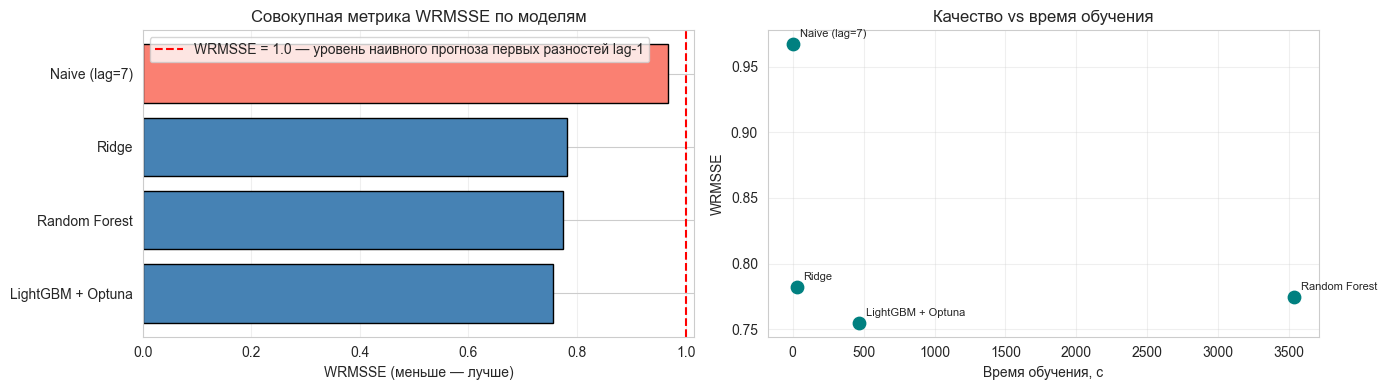

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

order = comparison.index.tolist()
colors = ['salmon' if m == 'Naive (lag=7)' else 'steelblue' for m in order]
axes[0].barh(order, comparison['WRMSSE'], color=colors, edgecolor='black')
axes[0].axvline(1.0, color='red', linestyle='--', label='WRMSSE = 1.0 — уровень наивного прогноза первых разностей lag-1')
axes[0].set_xlabel('WRMSSE (меньше — лучше)')
axes[0].set_title('Совокупная метрика WRMSSE по моделям')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

axes[1].scatter(comparison['fit_time_s'], comparison['WRMSSE'], s=80, color='teal')
for m in order:
    axes[1].annotate(m, (comparison.loc[m, 'fit_time_s'], comparison.loc[m, 'WRMSSE']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')
axes[1].set_xlabel('Время обучения, с')
axes[1].set_ylabel('WRMSSE')
axes[1].set_title('Качество vs время обучения')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.8.1.3 Прогноз vs факт на примере одного ряда

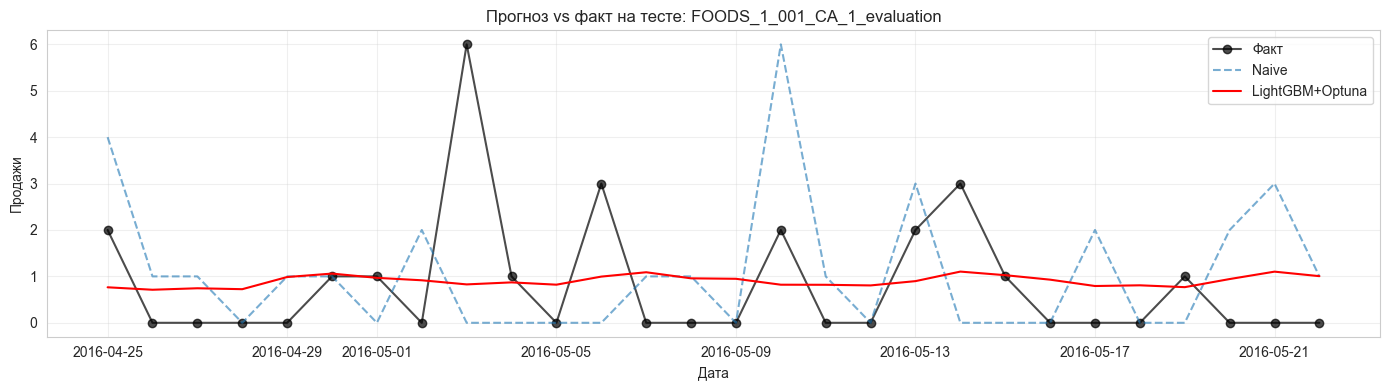

In [98]:
sample_id = test_df['id'].iloc[0]
sample = test_df[test_df['id'] == sample_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(sample['date'], sample['sales'], 'o-', label='Факт', color='black', alpha=0.7)
plt.plot(sample['date'], sample['pred_naive'], '--', label='Naive', alpha=0.6)
plt.plot(sample['date'], sample['pred_lgbm'], '-', label='LightGBM+Optuna', color='red')
plt.title(f'Прогноз vs факт на тесте: {sample_id}')
plt.xlabel('Дата'); plt.ylabel('Продажи')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

### 5.8.1.4 Важность признаков финальной модели LightGBM

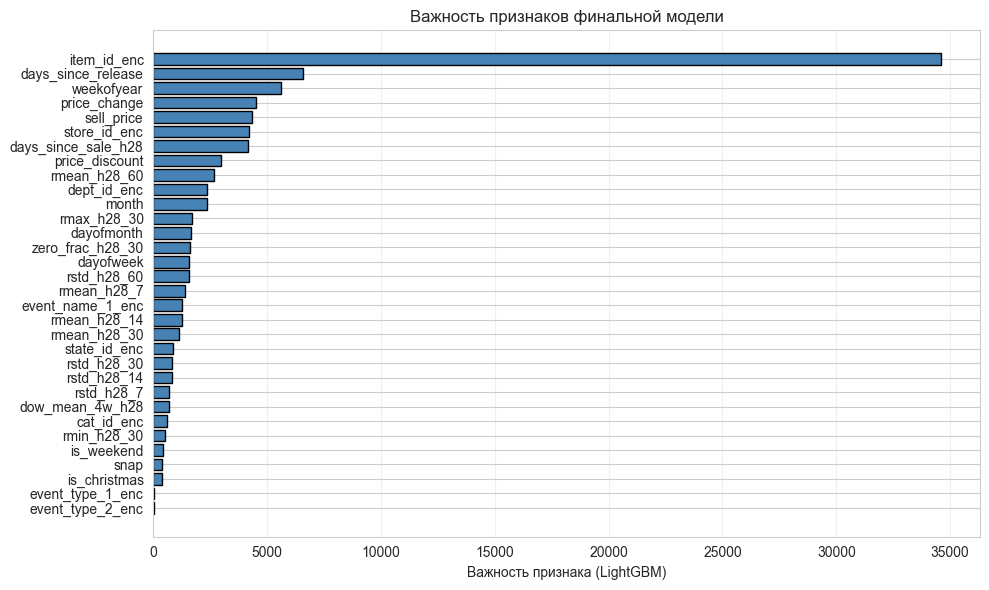

In [99]:
imp = pd.Series(lgbm.feature_importances_, index=FEATURES).sort_values(ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(imp.index, imp.values, color='steelblue', edgecolor='black')
plt.xlabel('Важность признака (LightGBM)')
plt.title('Важность признаков финальной модели')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Выводы по baseline-решению:**

1. **Все модели превзошли наивный baseline.** WRMSSE снизился с ~1.0 (Naive) до 0.755 (LightGBM+Optuna) — на ~22%. Это подтверждает, что в данных есть закономерности, которые улавливают ML модели.

2. **Прогрессия метрики:** Naive (0.967) → Ridge (0.782) → Random Forest (0.775) → LightGBM+Optuna (0.755). Разрыв между моделями небольшой: основной скачок даёт уже переход от Naive к любой ML-модели, а разница между Ridge, Random Forest и LightGBM составляет всего ~0.03 WRMSSE. Линейная Ridge улавливает вклад календаря, цены и leak-safe скользящих; деревья добавляют нелинейность и работу с категориальной иерархией товаров, но прирост умеренный.

3. **LightGBM с Tweedie-loss и Optuna — лучшая модель** по WRMSSE (0.755) при умеренном времени обучения финальной модели (470 с). Tweedie-loss подходит для прерывистого спроса с массой нулей, Optuna подбирает гиперпараметры без ручного перебора.

4. **Trade-off качество/время.** Random Forest обучается ~3534 с — в ~8 раз дольше финального LightGBM (470 с) — при этом уступает ему по всем метрикам. Для production LightGBM однозначно предпочтительнее. Ridge при этом самый быстрый (26 с) и отстаёт от лучшей модели всего на ~0.03 WRMSSE — как быстрый baseline он конкурентоспособен.

5. **Важность признаков.** С огромным отрывом лидирует `item_id_enc` — идентификатор товара определяет базовый уровень спроса сильнее любого динамического признака. Второй по значимости — `days_since_release` (период в течение которого продается товар), за ним `weekofyear` (годовая сезонность). Заметный вклад вносят ценовые признаки (`price_change`, `sell_price`, `price_discount`) и `store_id_enc` — из категориальной иерархии он значим, а вот `dept_id_enc`, `cat_id_enc` и `state_id_enc` — в нижней половине списка. `days_since_sale_h28` (давность последней продажи) также важен. Далее идёт группа leak-safe скользящих статистик (`rmean_h28_60`, `rmax_h28_30`, `rstd_h28_60`, `zero_frac_h28_30`, `rmean_h28_14/7/30`) и календарные признаки (`month`, `dayofmonth`, `dayofweek`). Минимальный вклад — у `snap`, `is_weekend`, `is_christmas` и признаков типа события (`event_type_1_enc`, `event_type_2_enc`); `event_name_1_enc` при этом заметно важнее обоих `event_type_*`.

## 6. Продвинутые модели прогнозирования

Две группы моделей:

- **Классические статистические** — отдельная модель на каждый ряд, опираются только на собственную историю ряда.
- **Нейросетевые** — одна *глобальная* модель на все ряды данных, вероятностный прогноз.

In [100]:
panel_full = (df[df['date'] < test_start][['id', 'date', 'sales']]
              .rename(columns={'id': 'unique_id', 'date': 'ds', 'sales': 'y'})
              .sort_values(['unique_id', 'ds'])
              .reset_index(drop=True))

test_full = test_df.copy()
results_adv = {}
timings_adv = {}

print(f'Рядов: {panel_full["unique_id"].nunique()}, '
      f'точек истории: {panel_full.shape[0]:,}, тестовых строк: {test_full.shape[0]:,}')

Рядов: 30490, точек истории: 45,088,780, тестовых строк: 853,720


### 6.1 Классические статистические модели

- **AutoETS** — экспоненциальное сглаживание (Error-Trend-Seasonal), автоподбор формы ошибки/тренда/сезонности.

- **Модели для прерывистого спроса** (intermittent demand) — отдельно оценивают *размер* спроса и *интервал* между ненулевыми продажами:
  - **CrostonOptimized** — классический метод Кростона с оптимизацией сглаживания;
  - **TSB** (Teunter-Syntetos-Babai) — устойчивее Кростона на «затухающих» рядах;
  - **IMAPA** — агрегация прогнозов по нескольким временным масштабам.

- **AutoARIMA** — авторегрессионная интегрированная скользящая средняя, автоподбор порядков.

ETS/ARIMA настроены на недельную сезонность (`season_length=7`). Ни одна из этих моделей не использует ковариаты (цену, SNAP, события).

In [101]:
MAX_HISTORY_DAYS = 730   # усечение истории: статистические модели опираются на недавнюю динамику
N_JOBS  = 4
BATCH   = 2000           # рядов в одном батче

# Усекаем историю каждого ряда до последних MAX_HISTORY_DAYS точек
panel_stat = panel_full.groupby('unique_id', group_keys=False).tail(MAX_HISTORY_DAYS)

all_ids = panel_stat['unique_id'].unique()
batches = [all_ids[i:i + BATCH] for i in range(0, len(all_ids), BATCH)]

In [102]:
def forecast_in_batches(models, label):
    """Прогноз по батчам рядов с прогресс-баром и ETA. models — список моделей StatsForecast."""
    parts = []
    t0 = time.time()
    sf = StatsForecast(models=models, freq='D', n_jobs=N_JOBS)
    for ids in tqdm(batches, desc=label, unit='батч'):
        chunk = panel_stat[panel_stat['unique_id'].isin(ids)]
        parts.append(sf.forecast(df=chunk, h=HORIZON).reset_index(drop=True))
    return pd.concat(parts, ignore_index=True), time.time() - t0

In [103]:
fast_models = [
    AutoETS(season_length=7),
    CrostonOptimized(),
    TSB(alpha_d=0.2, alpha_p=0.2),
    IMAPA(),
]
fcst, stat_fit_time = forecast_in_batches(fast_models, 'ETS+Croston+TSB+IMAPA')
print(f'ETS+Croston+TSB+IMAPA на всех рядах за {stat_fit_time / 60:.1f} мин')

ETS+Croston+TSB+IMAPA:   0%|          | 0/16 [00:00<?, ?батч/s]

ETS+Croston+TSB+IMAPA на всех рядах за 11.3 мин


In [104]:
fcst_arima, arima_fit_time = forecast_in_batches(
    [AutoARIMA(season_length=7, approximation=True, stepwise=True,
               max_p=2, max_q=2, max_P=1, max_Q=1, max_d=1, max_D=1)],
    'AutoARIMA')
print(f'AutoARIMA на всех рядах за {arima_fit_time / 60:.1f} мин')

AutoARIMA:   0%|          | 0/16 [00:00<?, ?батч/s]

AutoARIMA на всех рядах за 26.5 мин


In [105]:
for _d in (fcst, fcst_arima):
    _d['unique_id'] = _d['unique_id'].astype(str)
    _d['ds'] = pd.to_datetime(_d['ds'])

arima_cols = [c for c in fcst_arima.columns if c not in ('unique_id', 'ds')]
fcst = fcst.merge(fcst_arima[['unique_id', 'ds'] + arima_cols],
                  on=['unique_id', 'ds'], how='left')

assert 'AutoARIMA' in fcst.columns, \
    f'AutoARIMA не попал в fcst; колонки fcst_arima: {fcst_arima.columns.tolist()}'
print('Колонки прогноза после merge:', [c for c in fcst.columns if c not in ('unique_id', 'ds')])
print(f'Доля NaN в AutoARIMA после merge: {fcst["AutoARIMA"].isna().mean():.3f}')
fcst.head()

Колонки прогноза после merge: ['AutoETS', 'CrostonOptimized', 'TSB', 'IMAPA', 'AutoARIMA']
Доля NaN в AutoARIMA после merge: 0.000


,unique_id,ds,AutoETS,CrostonOptimized,TSB,IMAPA,AutoARIMA
0,FOODS_1_001_CA_1_evaluation,2016-04-25,0.716688,1.066436,0.885242,1.008482,0.716438
1,FOODS_1_001_CA_1_evaluation,2016-04-26,0.716688,1.066436,0.885242,1.008482,0.716438
2,FOODS_1_001_CA_1_evaluation,2016-04-27,0.716688,1.066436,0.885242,1.008482,0.716438
3,FOODS_1_001_CA_1_evaluation,2016-04-28,0.716688,1.066436,0.885242,1.008482,0.716438
4,FOODS_1_001_CA_1_evaluation,2016-04-29,0.716688,1.066436,0.885242,1.008482,0.716438


In [106]:
fcst = fcst.loc[:, ~fcst.columns.str.startswith('index')]
stat_models = [c for c in fcst.columns if c not in ('unique_id', 'ds')]
print('Статистические модели:', stat_models)

Статистические модели: ['AutoETS', 'CrostonOptimized', 'TSB', 'IMAPA', 'AutoARIMA']


In [107]:
test_full = test_df.copy()
test_full = test_full.merge(
    fcst.rename(columns={'unique_id': 'id', 'ds': 'date'}),
    on=['id', 'date'], how='left')

revenue = (train_df['sales'] * train_df['sell_price']).groupby(train_df['id']).sum()
weights_all = revenue / revenue.sum()

for name in stat_models:
    test_full[name] = np.clip(test_full[name].fillna(0), 0, None)

    rmsse = rmsse_per_series(train_df, test_full, name)
    weights = weights_all.reindex(rmsse.index).fillna(0)
    wrmsse = float((rmsse * weights).sum() / weights.sum()) if weights.sum() > 0 else np.nan

    mae  = mean_absolute_error(test_full['sales'], test_full[name])
    rmse = np.sqrt(mean_squared_error(test_full['sales'], test_full[name]))

    results_adv[name] = {'MAE': mae, 'RMSE': rmse, 'RMSSE': rmsse.mean(), 'WRMSSE': wrmsse}
    timings_adv[name] = arima_fit_time if name == 'AutoARIMA' else stat_fit_time
    print(f'{name}:', {k: round(v, 3) for k, v in results_adv[name].items()})

AutoETS: {'MAE': 1.041, 'RMSE': 2.172, 'RMSSE': 2.379, 'WRMSSE': 0.753}
CrostonOptimized: {'MAE': 1.094, 'RMSE': 2.249, 'RMSSE': 2.599, 'WRMSSE': 0.786}
TSB: {'MAE': 1.072, 'RMSE': 2.232, 'RMSSE': 2.393, 'WRMSSE': 0.776}
IMAPA: {'MAE': 1.06, 'RMSE': 2.223, 'RMSSE': 2.565, 'WRMSSE': 0.768}
AutoARIMA: {'MAE': 1.055, 'RMSE': 2.203, 'RMSSE': 2.449, 'WRMSSE': 0.764}


### 6.2 Нейросетевая модель (DeepAR)

**DeepAR** — авторегрессионная LSTM-сеть, обучаемая сразу на всех рядах как одна *глобальная* модель: она переносит закономерности между рядами, что важно для коротких и разреженных рядов. Прогноз вероятностный — на каждый шаг предсказывается распределение; используется **отрицательное биномиальное** (`NegativeBinomial`), естественное для счётных данных с большой долей нулей.

In [108]:
print(torch.__version__, torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.6.0+cu124 True
NVIDIA GeForce RTX 4070 Ti SUPER


In [109]:
FUTR_EXOG = ['sell_price', 'price_change', 'snap', 'has_event', 'dayofweek', 'is_weekend']

panel_ex = (df[df['date'] < test_start][['id', 'date', 'sales'] + FUTR_EXOG]
            .rename(columns={'id': 'unique_id', 'date': 'ds', 'sales': 'y'})
            .sort_values(['unique_id', 'ds'])
            .reset_index(drop=True))
panel_ex[FUTR_EXOG] = panel_ex[FUTR_EXOG].fillna(0)

In [110]:
deepar = DeepAR(
    h=HORIZON,
    input_size=2 * HORIZON,
    lstm_n_layers=2,
    lstm_hidden_size=128,
    scaler_type='robust',          # устойчивее 'standard' на нулях/выбросах
    loss=DistributionLoss(distribution='NegativeBinomial', level=[80]),
    futr_exog_list=FUTR_EXOG,      # ковариаты, известные в будущем
    max_steps=3000,
    start_padding_enabled=True,    # короткие ряды дополняются слева, не отсеиваются
    random_seed=RANDOM_STATE,
)

nf = NeuralForecast(models=[deepar], freq='D')

Seed set to 42


In [111]:
t0 = time.time()
nf.fit(df=panel_ex)
deepar_fit_time = time.time() - t0
print(f'DeepAR с ковариатами обучен за {deepar_fit_time / 60:.1f} мин')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
You are using a CUDA device ('NVIDIA GeForce RTX 4070 Ti SUPER') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | loss         | DistributionLoss | 3      | train
1 | valid_loss   | MAE              | 0      | train
2 | padder_train | ConstantPad1d    | 0      | train
3 | scaler       | TemporalNorm     | 0      | train
4 | hist_encoder | LSTM             | 202 K  | train
5 | decoder      | MLP              | 258    | train
----------------------------------------------------------
202 K     Train

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=3000` reached.


DeepAR с ковариатами обучен за 1.6 мин


In [112]:
futr_df = (test_df[['id', 'date'] + FUTR_EXOG]
           .rename(columns={'id': 'unique_id', 'date': 'ds'})
           .sort_values(['unique_id', 'ds'])
           .reset_index(drop=True))
futr_df[FUTR_EXOG] = futr_df[FUTR_EXOG].fillna(0)

fc_dl = nf.predict(futr_df=futr_df).reset_index(drop=True)

point_col = 'DeepAR' if 'DeepAR' in fc_dl.columns else next(
    c for c in fc_dl.columns if c.startswith('DeepAR') and '-' not in c)

test_full = test_full.merge(
    fc_dl[['unique_id', 'ds', point_col]].rename(
        columns={'unique_id': 'id', 'ds': 'date', point_col: 'DeepAR'}),
    on=['id', 'date'], how='left')

test_full['DeepAR'] = np.clip(test_full['DeepAR'].fillna(0), 0, None)

rmsse = rmsse_per_series(train_df, test_full, 'DeepAR')
weights = weights_all.reindex(rmsse.index).fillna(0)
wrmsse = float((rmsse * weights).sum() / weights.sum())
mae  = mean_absolute_error(test_full['sales'], test_full['DeepAR'])
rmse = np.sqrt(mean_squared_error(test_full['sales'], test_full['DeepAR']))

results_adv['DeepAR'] = {'MAE': mae, 'RMSE': rmse, 'RMSSE': rmsse.mean(), 'WRMSSE': wrmsse}
timings_adv['DeepAR'] = deepar_fit_time
print('DeepAR:', {k: round(v, 3) for k, v in results_adv['DeepAR'].items()})

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

DeepAR: {'MAE': 1.086, 'RMSE': 2.257, 'RMSSE': 2.395, 'WRMSSE': 0.771}


### 6.3 Итоговое сравнение всех моделей

In [113]:
comparison_full = pd.DataFrame({**results, **results_adv}).T
comparison_full['fit_time_s'] = pd.Series({**timings, **timings_adv})
comparison_full = comparison_full.round(3).sort_values('WRMSSE')
print('Все модели на полном наборе рядов:')
comparison_full

Все модели на полном наборе рядов:


,MAE,RMSE,RMSSE,WRMSSE,fit_time_s
AutoETS,1.041,2.172,2.379,0.753,675.868
LightGBM + Optuna,1.049,2.146,2.466,0.755,470.141
AutoARIMA,1.055,2.203,2.449,0.764,1590.226
IMAPA,1.060,2.223,2.565,0.768,675.868
DeepAR,1.086,2.257,2.395,0.771,98.622
Random Forest,1.082,2.222,2.551,0.775,3534.527
TSB,1.072,2.232,2.393,0.776,675.868
Ridge,1.086,2.240,2.535,0.782,26.837
CrostonOptimized,1.094,2.249,2.599,0.786,675.868
Naive (lag=7),1.245,2.682,2.998,0.967,0.000


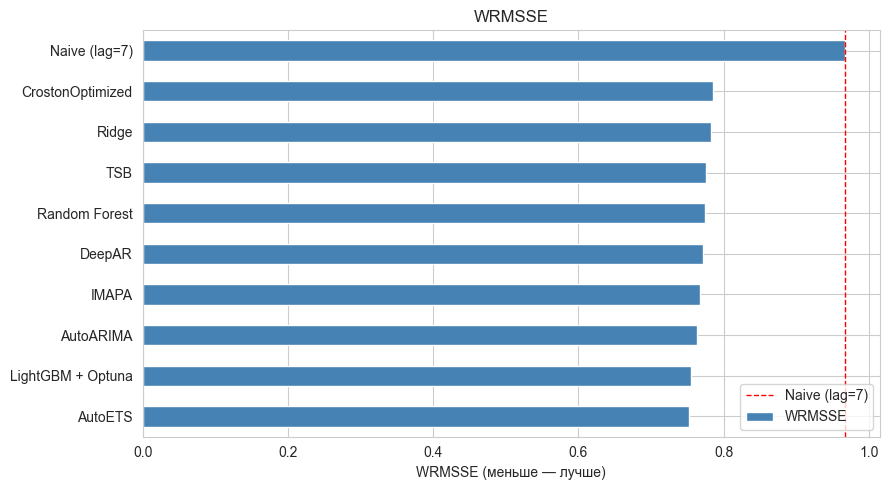

In [114]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison_full['WRMSSE'].sort_values(ascending=True).plot.barh(ax=ax, color='steelblue')
if 'Naive (lag=7)' in comparison_full.index:
    ax.axvline(comparison_full.loc['Naive (lag=7)', 'WRMSSE'],
               color='red', ls='--', lw=1, label='Naive (lag=7)')
    ax.legend()
ax.set_title('WRMSSE')
ax.set_xlabel('WRMSSE (меньше — лучше)')
plt.tight_layout()
plt.show()

### 6.4 Интерпретация результатов

Итоговый рейтинг по упрощённой WRMSSE на полном наборе рядов (нижний уровень, 30 490 рядов):
- AutoETS **0.753**
- LightGBM + Optuna 0.755
- AutoARIMA 0.764
- IMAPA 0.768
- DeepAR 0.771
- Random Forest 0.775
- TSB 0.776
- Ridge 0.782
- CrostonOptimized 0.786
- Naive (lag=7) 0.967

Все модели превосходят наивный baseline (Seasonal Naive, 0.967), но разброс между остальными невелик: от 0.753 до 0.786, около 0.03 WRMSSE.

**AutoETS — лучшая модель по упрощённой WRMSSE (0.753)**, немного опередившая даже LightGBM с feature engineering (0.755). При этом прогноз AutoETS почти плоский: на преимущественно нулевом ряде это фактически константа на все 28 дней горизонта. 

**Модели для прерывистого спроса не дали выигрыша по WRMSSE.** CrostonOptimized (0.786); TSB (0.776) и IMAPA (0.768). Причина в самой метрике: WRMSSE смещена к высокооборотным рядам, которые не являются прерывистыми; там сглаживание ETS работает, а преимущество Croston/TSB проявляется на низкооборотных рядах, чей вес в WRMSSE мал.

**Нейросетевая модель DeepAR (0.771)** По *невзвешенному* RMSSE (2.395) DeepAR уступает только AutoETS (2.379) и TSB (2.393), обходя в том числе LightGBM (2.466) — то есть на «среднем» ряде глобальная LSTM конкурентоспособна, а проигрывает именно на высокооборотных рядах, которые и определяют WRMSSE.

**Вывод.** На упрощённой WRMSSE хорошо настроенное экспоненциальное сглаживание идет на одном уровне с бустингом: разрыв между AutoETS и LightGBM — всего 0.002. Тем не менее развивать имеет смысл именно LightGBM: у него лучший RMSE (2.146), он единственный использует ковариаты (цену, SNAP, события) и категориальную иерархию, и у него есть возможности для улучшения, которых нет у AutoETS, — дообучение на полной истории (train + val), снижение дисперсии seed-ансамблем, ансамблирование с DeepAR/AutoETS и, главное, использование самых информативных признаков — коротких лагов — через рекурсивный прогноз без утечки.

## 7. Улучшение итоговой модели и итоговая официальная метрика WRMSSE

На текущий момент лучшие модели: AutoETS (упрощённая WRMSSE 0.753) и LightGBM + Optuna (0.755). Дальше развиваем именно LightGBM: в отличие от AutoETS он показывает лучший RMSE, использует ковариаты (цену, SNAP, события) и категориальную иерархию, и у него есть возможности для улучшения, которых нет у AutoETS.

Дальнейшее развитие модели:

1. **Улучшение прогноза**: дообучение LightGBM на полной доступной истории (train + val), снижение дисперсии за счёт seed-ансамбля, ансамбль с DeepAR/AutoETS с весами, **подобранными на отложенном валидационном окне**, и — ключевое — **калибровка масштаба прогноза множителем, тоже подобранным на валидации**.
2. **Возврат коротких лагов через рекурсию**: основная модель обходится без коротких лагов — все её скользящие статистики сдвинуты на горизонт 28 дней (leak-safe). Рекурсивный 28-дневный прогноз позволяет добавить `lag_1 … lag_14` и короткие скользящие без утечки: дни горизонта предсказываются по очереди, а лаги пересчитываются из собственных прогнозов модели, а не из будущих фактов.
3. **Расчет финальной официальной метрики**: расчёт WRMSSE так, как она считалась в соревновании M5 — по **12 уровням иерархии** (42 840 рядов), а не только по нижнему уровню, как упрощенная метрика.

### 7.1 Развитие LightGBM: дообучение на полной доступной истории (train+val), seed-ансамбль, подбор весов и калибровка на валидации.

Четыре способа улучшения качества предсказания модели:

- **Дообучение на на полной доступной истории (train + val)** Валидация была нужна только для Optuna; после фиксации гиперпараметров финальную модель обучаем на всех данных до теста — она видит ещё 28 дополнительных дней, ближайших к горизонту прогноза.
- **Seed-ансамбль.** LightGBM стохастичен (`subsample`, `colsample_bytree`); усреднение прогнозов нескольких моделей с разными `random_state` снижает дисперсию без переобучения.
- **Ансамбль с DeepAR/AutoETS, веса подобраны на валидации.** DeepAR (глобальная LSTM) и AutoETS ошибаются *иначе*, чем бустинг, поэтому могут дать выигрыш от разнообразия ошибок. Веса подбираются на **по отложенному валидационному окну**.
- **Калибровка масштаба (множитель, подобранный на валидации).** Под RMSSE на прерывистом спросе условное среднее — смещенная точка: оптимум достигается ниже. Подбираем множитель α по сетке на валидации — сначала глобальный, затем покатегорийный (FOODS / HOUSEHOLD / HOBBIES), причём покатегорийный использыется **только если он бьёт глобальный на валидации**. α = 1 всегда в сетке, поэтому калибровка не может ухудшить отложенную метрику.

In [115]:
gc.collect()
SEEDS = [42, 7, 2024]
FEAT  = list(X_train.columns)
CAT_IDX = [FEAT.index(c) for c in CAT_FEATURES if c in FEAT]

n_rounds   = best_params.get('n_estimators', 100)
DS_PARAMS  = {'max_bin': best_params['max_bin']} if 'max_bin' in best_params else {}
lgb_params = {k: v for k, v in best_params.items()
              if k not in ('n_estimators', 'random_state', 'max_bin')}


def _seed_ensemble(dtrain, X_pred, seeds):
    preds = np.zeros(X_pred.shape[0], dtype=np.float64)
    for s in seeds:
        booster = lgb.train({**lgb_params, 'seed': s}, dtrain, num_boost_round=n_rounds)
        preds += np.clip(booster.predict(X_pred), 0, None)
        del booster; gc.collect()
    return preds / len(seeds)


def _to_f32(frame):
    return np.ascontiguousarray(frame[FEAT].to_numpy(dtype=np.float32))


X_tr_np = _to_f32(X_train)
d_tr = lgb.Dataset(X_tr_np, label=y_train.to_numpy(), params=DS_PARAMS,
                   categorical_feature=CAT_IDX, free_raw_data=True).construct()
del X_tr_np; gc.collect()                       # сырьё освобождено, остаётся компактный бин-Dataset
X_val_np = _to_f32(X_val)
lgbm_val = _seed_ensemble(d_tr, X_val_np, SEEDS)
del d_tr, X_val_np; gc.collect()

n_tr, n_va = len(X_train), len(X_val)
X_trval_np = np.empty((n_tr + n_va, len(FEAT)), dtype=np.float32)
for j, col in enumerate(FEAT):
    X_trval_np[:n_tr, j] = X_train[col].to_numpy(dtype=np.float32)
    X_trval_np[n_tr:, j] = X_val[col].to_numpy(dtype=np.float32)
y_trval = np.concatenate([y_train.to_numpy(), y_val.to_numpy()])
print(f'Train+val: {X_trval_np.shape[0]:,} строк, {X_trval_np.shape[1]} признаков (float32)')

d_trval = lgb.Dataset(X_trval_np, label=y_trval, params=DS_PARAMS,
                      categorical_feature=CAT_IDX, free_raw_data=True).construct()
del X_trval_np, y_trval; gc.collect()

X_test_np = _to_f32(X_test)
t0 = time.time()
lgbm_test = _seed_ensemble(d_trval, X_test_np, SEEDS)
lgbm_full_time = time.time() - t0
del d_trval, X_test_np; gc.collect()

assert (test_full['id'].values == test_df['id'].values).all()
assert (test_full['date'].values == test_df['date'].values).all()
test_full['LGBM_full'] = lgbm_test
print(f'Seed-ансамбль LightGBM ({len(SEEDS)} seeds): val-прогноз (train) и '
      f'test-прогноз (train+val) за {lgbm_full_time:.1f}s')

Train+val: 45,088,780 строк, 32 признаков (float32)
Seed-ансамбль LightGBM (3 seeds): val-прогноз (train) и test-прогноз (train+val) за 1287.1s


In [116]:
panel_tr_stat = (df[df['date'] < val_start][['id', 'date', 'sales']]
                 .rename(columns={'id': 'unique_id', 'date': 'ds', 'sales': 'y'})
                 .sort_values(['unique_id', 'ds']).reset_index(drop=True)
                 .groupby('unique_id', group_keys=False).tail(MAX_HISTORY_DAYS))
ids_v = panel_tr_stat['unique_id'].unique()
batches_v = [ids_v[i:i + BATCH] for i in range(0, len(ids_v), BATCH)]

sf_v = StatsForecast(models=[AutoETS(season_length=7)], freq='D', n_jobs=N_JOBS)
parts = []
for ids in tqdm(batches_v, desc='AutoETS (val)', unit='батч'):
    chunk = panel_tr_stat[panel_tr_stat['unique_id'].isin(ids)]
    parts.append(sf_v.forecast(df=chunk, h=HORIZON).reset_index(drop=True))
ets_val_fc = (pd.concat(parts, ignore_index=True)
              .rename(columns={'unique_id': 'id', 'ds': 'date'}))

panel_tr_ex = (df[df['date'] < val_start][['id', 'date', 'sales'] + FUTR_EXOG]
               .rename(columns={'id': 'unique_id', 'date': 'ds', 'sales': 'y'})
               .sort_values(['unique_id', 'ds']).reset_index(drop=True))
panel_tr_ex[FUTR_EXOG] = panel_tr_ex[FUTR_EXOG].fillna(0)

deepar_v = DeepAR(
    h=HORIZON, input_size=2 * HORIZON,
    lstm_n_layers=2, lstm_hidden_size=128, scaler_type='robust',
    loss=DistributionLoss(distribution='NegativeBinomial', level=[80]),
    futr_exog_list=FUTR_EXOG, max_steps=2000,
    start_padding_enabled=True, random_seed=RANDOM_STATE)
nf_v = NeuralForecast(models=[deepar_v], freq='D')
nf_v.fit(df=panel_tr_ex)

futr_v = (val_df[['id', 'date'] + FUTR_EXOG]
          .rename(columns={'id': 'unique_id', 'date': 'ds'})
          .sort_values(['unique_id', 'ds']).reset_index(drop=True))
futr_v[FUTR_EXOG] = futr_v[FUTR_EXOG].fillna(0)
dl_v = nf_v.predict(futr_df=futr_v).reset_index(drop=True)
pc = ('DeepAR' if 'DeepAR' in dl_v.columns
      else next(c for c in dl_v.columns if c.startswith('DeepAR') and '-' not in c))
deepar_val_fc = (dl_v[['unique_id', 'ds', pc]]
                 .rename(columns={'unique_id': 'id', 'ds': 'date', pc: 'DeepAR'}))

del nf_v, panel_tr_ex, panel_tr_stat; gc.collect()
print('Готовы валидационные прогнозы AutoETS и DeepAR.')

AutoETS (val):   0%|          | 0/16 [00:00<?, ?батч/s]

Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type             | Params | Mode 
----------------------------------------------------------
0 | loss         | DistributionLoss | 3      | train
1 | valid_loss   | MAE              | 0      | train
2 | padder_train | ConstantPad1d    | 0      | train
3 | scaler       | TemporalNorm     | 0      | train
4 | hist_encoder | LSTM             | 202 K  | train
5 | decoder      | MLP              | 258    | train
----------------------------------------------------------
202 K     Trainable params
3         Non-trainable params
202 K     Total params
0.810     Total estimated model params size (MB)
8         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=2000` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

Готовы валидационные прогнозы AutoETS и DeepAR.


In [117]:
val_eval = val_df[['id', 'date', 'sales']].copy()
val_eval['LGBM'] = np.clip(lgbm_val, 0, None)
val_eval = (val_eval.merge(deepar_val_fc, on=['id', 'date'], how='left')
                    .merge(ets_val_fc,    on=['id', 'date'], how='left'))
for c in ['DeepAR', 'AutoETS']:
    val_eval[c] = np.clip(val_eval[c].fillna(0), 0, None)

BASE = ['LGBM', 'DeepAR', 'AutoETS']
P = val_eval[BASE].values.astype('float64')
y = val_eval['sales'].values.astype('float64')

tr_sorted = train_df.sort_values(['id', 'date'])
d2 = tr_sorted.groupby('id')['sales'].diff() ** 2
scale = d2.groupby(tr_sorted['id']).mean().clip(lower=1e-8)
row_scale = val_eval['id'].map(scale).values
row_w     = val_eval['id'].map(weights_all).fillna(0).values
row_wt    = np.where(row_scale > 0, row_w / row_scale, 0.0)

def surrogate(w):
    r = y - P @ w
    return float(np.sum(row_wt * r * r))

res = minimize(surrogate, x0=np.array([1.0, 0.0, 0.0]), method='SLSQP',
               bounds=[(0.0, 1.0)] * len(BASE),
               constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1.0},),
               options={'ftol': 1e-12, 'maxiter': 500})
w_opt = np.clip(res.x, 0, None); w_opt = w_opt / w_opt.sum()

def val_wrmsse(weights):
    val_eval['_ens'] = np.clip(P @ weights, 0, None)
    rm = rmsse_per_series(train_df, val_eval, '_ens')
    wts = weights_all.reindex(rm.index).fillna(0)
    return float((rm * wts).sum() / wts.sum())

w_lgbm = np.array([1.0, 0.0, 0.0])
score_opt, score_lgbm = val_wrmsse(w_opt), val_wrmsse(w_lgbm)
W = w_opt if score_opt <= score_lgbm else w_lgbm
val_eval.drop(columns='_ens', inplace=True)

print('Веса ансамбля (подобраны на валидации):', dict(zip(BASE, np.round(W, 3))))
print(f'val-WRMSSE: чистый LightGBM = {score_lgbm:.4f} | ансамбль = {min(score_opt, score_lgbm):.4f}')

val_eval = val_eval.merge(val_df[['id', 'date', 'cat_id']].drop_duplicates(),
                          on=['id', 'date'], how='left')

Веса ансамбля (подобраны на валидации): {'LGBM': 0.638, 'DeepAR': 0.124, 'AutoETS': 0.237}
val-WRMSSE: чистый LightGBM = 0.7345 | ансамбль = 0.7255


In [118]:
val_eval['_ENS'] = np.clip(P @ W, 0, None)


def _val_wrmsse_col(col):
    rm = rmsse_per_series(train_df, val_eval, col)
    wts = weights_all.reindex(rm.index).fillna(0)
    return float((rm * wts).sum() / wts.sum())


alphas = np.round(np.arange(0.80, 1.151, 0.01), 3)

# 1) глобальный множитель
def _score_global(a):
    val_eval['_cal'] = np.clip(val_eval['_ENS'].values * a, 0, None)
    return _val_wrmsse_col('_cal')

glob = {float(a): _score_global(a) for a in alphas}
alpha_glob = min(glob, key=glob.get)

# 2) покатегорийные множители — независимый подбор alpha внутри каждой категории
cat_alpha = {}
ens_arr = val_eval['_ENS'].values
for cat in val_eval['cat_id'].dropna().unique():
    m = (val_eval['cat_id'] == cat).values

    def _score_cat(a, m=m):
        col = ens_arr.copy()
        col[m] = np.clip(col[m] * a, 0, None)
        val_eval['_cal'] = col
        return _val_wrmsse_col('_cal')

    cat_alpha[cat] = float(min(alphas, key=_score_cat))

cal = val_eval['cat_id'].map(cat_alpha).fillna(alpha_glob).values
val_eval['_cal'] = np.clip(ens_arr * cal, 0, None)
score_cat = _val_wrmsse_col('_cal')
score_glob = glob[alpha_glob]
score_plain = glob[1.0]

USE_PERCAT = score_cat < score_glob
val_eval.drop(columns=['_ENS', '_cal'], inplace=True)

print(f'val-WRMSSE  без калибровки = {score_plain:.4f}  |  '
      f'глобальный alpha={alpha_glob:.2f} -> {score_glob:.4f}  |  '
      f'по категориям -> {score_cat:.4f}')
print('Выбрано:',
      ('покатегорийно ' + str({k: round(v, 2) for k, v in cat_alpha.items()}))
      if USE_PERCAT else f'глобально alpha={alpha_glob:.2f}')

val-WRMSSE  без калибровки = 0.7255  |  глобальный alpha=0.97 -> 0.7248  |  по категориям -> 0.7247
Выбрано: покатегорийно {'FOODS': 0.97, 'HOBBIES': 0.96, 'HOUSEHOLD': 0.96}


In [119]:
ens_raw = (W[0] * test_full['LGBM_full']
           + W[1] * test_full['DeepAR']
           + W[2] * test_full['AutoETS']).values
mult = (test_full['cat_id'].map(cat_alpha).fillna(alpha_glob).values
        if USE_PERCAT else alpha_glob)
test_full['ENS_opt'] = np.clip(ens_raw * mult, 0, None)

if 'weights_all' not in dir():
    revenue = (train_df['sales'] * train_df['sell_price']).groupby(train_df['id']).sum()
    weights_all = revenue / revenue.sum()

def eval_light(pred_col):
    rmsse = rmsse_per_series(train_df, test_full, pred_col)
    w = weights_all.reindex(rmsse.index).fillna(0)
    return {'MAE': mean_absolute_error(test_full['sales'], test_full[pred_col]),
            'RMSE': float(np.sqrt(mean_squared_error(test_full['sales'], test_full[pred_col]))),
            'RMSSE': float(rmsse.mean()),
            'WRMSSE': float((rmsse * w).sum() / w.sum())}

results_ens, timings_ens = {}, {}
ENS_LABEL = f'Ансамбль LGBM/DeepAR/ETS (val-веса {tuple(np.round(W, 2))})'
for label, col in [('LightGBM full (train+val, seed-ens)', 'LGBM_full'),
                   (ENS_LABEL, 'ENS_opt')]:
    results_ens[label] = eval_light(col)
    timings_ens[label] = lgbm_full_time
    print(f'{label}:', {k: round(v, 3) for k, v in results_ens[label].items()})

LightGBM full (train+val, seed-ens): {'MAE': 1.039, 'RMSE': 2.128, 'RMSSE': 2.454, 'WRMSSE': 0.75}
Ансамбль LGBM/DeepAR/ETS (val-веса (0.64, 0.12, 0.24)): {'MAE': 1.024, 'RMSE': 2.102, 'RMSSE': 2.395, 'WRMSSE': 0.74}


In [120]:
comparison_v2 = pd.DataFrame({**results, **results_adv, **results_ens}).T
comparison_v2['fit_time_s'] = pd.Series({**timings, **timings_adv, **timings_ens})
comparison_v2 = comparison_v2.round(3).sort_values('WRMSSE')
comparison_v2

,MAE,RMSE,RMSSE,WRMSSE,fit_time_s
"Ансамбль LGBM/DeepAR/ETS (val-веса (0.64, 0.12, 0.24))",1.024,2.102,2.395,0.740,1287.100
"LightGBM full (train+val, seed-ens)",1.039,2.128,2.454,0.750,1287.100
AutoETS,1.041,2.172,2.379,0.753,675.868
LightGBM + Optuna,1.049,2.146,2.466,0.755,470.141
AutoARIMA,1.055,2.203,2.449,0.764,1590.226
IMAPA,1.060,2.223,2.565,0.768,675.868
DeepAR,1.086,2.257,2.395,0.771,98.622
Random Forest,1.082,2.222,2.551,0.775,3534.527
TSB,1.072,2.232,2.393,0.776,675.868
Ridge,1.086,2.240,2.535,0.782,26.837


### 7.2 Рекурсивный прогноз: честная оценка без утечки коротких лагов

Все модели используют только leak-safe признаки: все скользящие статистики сдвинуты на горизонт (t−28). Короткие лаги (`lag_1 … lag_14`) и скользящие по последним дням (`rmean_7/28`, `rstd_7/28`) — потенциально самые информативные признаки, однако их использование означало бы утечку: для дня t+k факты продаж дней t+1 … t+k−1 в реальности недоступны.

Рекурсивный прогноз позволяет использовать их честно: обучаем отдельную модель на расширенном наборе признаков (`FEATURES` + короткие лаги), а тестовые дни предсказываем по очереди — короткие лаги и короткие скользящие каждого следующего дня пересчитываются из собственных прогнозов модели.

In [121]:
REC_SHORT_LAGS = [1, 2, 7, 8, 14]
SHORT_FEATS = [f'lag_{L}' for L in REC_SHORT_LAGS] + ['rmean_7', 'rmean_28', 'rstd_7', 'rstd_28']
FEATURES_REC = FEATURES + SHORT_FEATS

for frame in (train_df, val_df, test_df):
    for c in SHORT_FEATS:
        frame[c] = frame[c].astype('float32')
gc.collect()

# Обучение lgbm_rec — как в 5.7.3.2 (те же гиперпараметры, веса рядов и early stopping),
# но с расширенным набором признаков; число деревьев подбирается заново
t0 = time.time()
lgbm_rec = lgb.LGBMRegressor(**{**best_params, 'n_estimators': 3000})
lgbm_rec.fit(train_df[FEATURES_REC], y_train,
             sample_weight=train_df['w'],
             eval_set=[(val_df[FEATURES_REC], y_val)],
             eval_sample_weight=[val_df['w']],
             categorical_feature=CAT_FEATURES,
             callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(0)])
rec_train_time = time.time() - t0
gc.collect()
print(f'lgbm_rec: {len(FEATURES_REC)} признаков, '
      f'{int(lgbm_rec.best_iteration_ or 3000)} деревьев, обучение {rec_train_time:.1f}s')

test_dates = sorted(test_df['date'].unique())
hist_start = pd.Timestamp(test_dates[0]) - pd.Timedelta(days=28)

sw_src = df.loc[(df['date'] >= hist_start) & (df['date'] < test_start), ['id', 'date', 'sales']]
sales_wide = sw_src.pivot(index='id', columns='date', values='sales').astype('float32')
for d in test_dates:
    sales_wide[d] = np.float32('nan')
sales_wide = sales_wide.sort_index(axis=1)
date_list = list(sales_wide.columns)
date_pos = {d: i for i, d in enumerate(date_list)}

test_by_date = {d: g.set_index('id') for d, g in test_df.groupby('date')}
preds_rec = {}
NUM_REC = [c for c in FEATURES_REC if c not in CAT_FEATURES]

t0 = time.time()
for d in test_dates:
    j = date_pos[d]
    rows = test_by_date[d]
    X = rows[FEATURES_REC].copy()
    for L in REC_SHORT_LAGS:
        X[f'lag_{L}'] = sales_wide.loc[X.index, date_list[j - L]].to_numpy()
    win7, win28 = date_list[j - 7:j], date_list[j - 28:j]
    sw = sales_wide.loc[X.index]
    X['rmean_7']  = sw[win7].mean(axis=1).to_numpy()
    X['rmean_28'] = sw[win28].mean(axis=1).to_numpy()
    X['rstd_7']   = sw[win7].std(axis=1).to_numpy()
    X['rstd_28']  = sw[win28].std(axis=1).to_numpy()
    X[NUM_REC] = X[NUM_REC].fillna(0)

    p = np.clip(lgbm_rec.predict(X[FEATURES_REC]), 0, None)
    sales_wide.loc[X.index, d] = p.astype('float32')
    for sid, val in zip(X.index, p):
        preds_rec[(sid, d)] = val

rec_time = time.time() - t0
test_df['pred_lgbm_rec'] = [preds_rec[(sid, dt)] for sid, dt in zip(test_df['id'], test_df['date'])]
test_full['pred_lgbm_rec'] = test_df['pred_lgbm_rec'].to_numpy()

REC_LABEL = 'LightGBM рекурсивный (короткие лаги)'
results_ens[REC_LABEL] = evaluate(train_df, test_df, 'pred_lgbm_rec')
timings_ens[REC_LABEL] = rec_train_time + rec_time
delta = results_ens[REC_LABEL]['WRMSSE'] - results['LightGBM + Optuna']['WRMSSE']
print(f'{REC_LABEL}: ' + str({k: round(v, 3) for k, v in results_ens[REC_LABEL].items()})
      + f' | инференс {rec_time:.1f}s')
print(f"Эффект коротких лагов при рекурсивном прогнозе: WRMSSE "
      f"{results['LightGBM + Optuna']['WRMSSE']:.4f} (прямой leak-safe) -> "
      f"{results_ens[REC_LABEL]['WRMSSE']:.4f} (рекурсивный)  [{delta:+.4f}]")

lgbm_rec: 41 признаков, 1998 деревьев, обучение 1162.8s
LightGBM рекурсивный (короткие лаги): {'MAE': 1.07, 'RMSE': 2.087, 'RMSSE': 2.308, 'WRMSSE': 0.743} | инференс 17.2s
Эффект коротких лагов при рекурсивном прогнозе: WRMSSE 0.7547 (прямой leak-safe) -> 0.7432 (рекурсивный)  [-0.0115]


### 7.3 Официальная финальная WRMSSE: 12 уровней иерархии M5

Упрощённая метрика оценивает только нижний уровень (30 490 рядов товар-магазин). Официальная метрика соревнования агрегирует ошибку по **12 уровням** — всего 42 840 рядов:

| № | Уровень | Рядов |
|---|---|---|
| 1 | Все продажи Walmart | 1 |
| 2 | Штат | 3 |
| 3 | Магазин | 10 |
| 4 | Категория | 3 |
| 5 | Отдел | 7 |
| 6 | Штат × категория | 9 |
| 7 | Штат × отдел | 21 |
| 8 | Магазин × категория | 30 |
| 9 | Магазин × отдел | 70 |
| 10 | Товар | 3 049 |
| 11 | Товар × штат | 9 147 |
| 12 | Товар × магазин | 30 490 |

Правила расчёта (по официальному описанию M5):
- для каждого ряда каждого уровня RMSSE = √(MSE прогноза / MSE наивной модели первых разностей (lag-1) на истории);
- веса внутри уровня пропорциональны **выручке за последние 28 дней обучающей выборки** (валидационное окно) и суммируются в 1;
- каждый уровень входит с равным весом 1/12.

Прогнозы верхних уровней получаются суммированием прогнозов нижнего уровня (bottom-up). Агрегированные ряды глаже и предсказуемее, поэтому официальная WRMSSE обычно **ниже** упрощённой по нижнему уровню.

Калибровочный множитель применен к нижнему уровню; на верхние уровни он переносится тем же bottom-up суммированием.

In [122]:
KEY_COLS = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
mask = (df['date'] < test_start).values

hist = pd.DataFrame({
    'date':    df.loc[mask, 'date'].values,
    'sales':   df.loc[mask, 'sales'].values.astype('float32'),
    'dollars': (df.loc[mask, 'sales'] * df.loc[mask, 'sell_price']).values.astype('float32'),
})
for c in KEY_COLS:
    hist[c] = df.loc[mask, c].astype('category').values
gc.collect()

hist_last = hist[hist['date'] >= val_start]
print(f'История: {hist.shape[0]:,} строк; окно весов: {hist_last.shape[0]:,} строк '
      f'({pd.Timestamp(val_start).date()} — {pd.Timestamp(hist_last["date"].max()).date()})')

История: 45,088,780 строк; окно весов: 853,720 строк (2016-03-28 — 2016-04-24)


In [123]:
LEVELS = [
    ('1. Total',            []),
    ('2. State',            ['state_id']),
    ('3. Store',            ['store_id']),
    ('4. Category',         ['cat_id']),
    ('5. Department',       ['dept_id']),
    ('6. State-Category',   ['state_id', 'cat_id']),
    ('7. State-Department', ['state_id', 'dept_id']),
    ('8. Store-Category',   ['store_id', 'cat_id']),
    ('9. Store-Department', ['store_id', 'dept_id']),
    ('10. Item',            ['item_id']),
    ('11. Item-State',      ['item_id', 'state_id']),
    ('12. Item-Store',      ['id']),
]


def _level_frame(keys, pred_col):
    """Для уровня: DataFrame с колонками num (MSE прогноза), scale, dollars по рядам уровня."""
    if keys == ['id']:
        tr = hist
        d2 = tr.groupby('id', observed=True)['sales'].diff() ** 2
        scale = d2.groupby(tr['id'], observed=True).mean().rename('scale')
        dollars = hist_last.groupby('id', observed=True)['dollars'].sum().rename('dollars')
    else:
        tr = (hist.groupby(keys + ['date'], observed=True)['sales'].sum()
                  .reset_index().sort_values(keys + ['date']))
        d2 = tr.groupby(keys, observed=True)['sales'].diff() ** 2
        scale = d2.groupby([tr[k] for k in keys], observed=True).mean().rename('scale')
        dollars = hist_last.groupby(keys, observed=True)['dollars'].sum().rename('dollars')

    te = test_full.groupby(keys + ['date'], observed=True)[['sales', pred_col]].sum()
    se = ((te['sales'] - te[pred_col]) ** 2)
    num = se.groupby(level=list(range(len(keys)))).mean().rename('num')

    out = (num.reset_index()
              .merge(scale.reset_index(), on=keys, how='left')
              .merge(dollars.reset_index(), on=keys, how='left'))
    return out


def wrmsse_official(pred_col, verbose=True):
    """Официальная WRMSSE M5: средняя по 12 уровням взвешенная RMSSE (bottom-up прогнозы)."""
    level_scores = {}
    for name, keys in LEVELS:
        if not keys:
            tr = hist.groupby('date', observed=True)['sales'].sum().sort_index()
            scale = np.mean(np.diff(tr.values) ** 2)
            te = test_full.groupby('date')[['sales', pred_col]].sum().sort_index()
            num = np.mean((te['sales'] - te[pred_col]).values ** 2)
            level_scores[name] = float(np.sqrt(num / scale))
            continue
        lf = _level_frame(keys, pred_col).dropna(subset=['scale'])
        lf = lf[lf['scale'] > 0]
        lf['rmsse'] = np.sqrt(lf['num'] / lf['scale'])
        lf['w'] = lf['dollars'].fillna(0)
        lf['w'] = lf['w'] / lf['w'].sum()
        level_scores[name] = float((lf['rmsse'] * lf['w']).sum())
    score = float(np.mean(list(level_scores.values())))
    if verbose:
        for name, s in level_scores.items():
            print(f'  {name:24s}: {s:.4f}')
        print(f'  {"WRMSSE (официальная)":24s}: {score:.4f}')
    return score, level_scores

In [124]:
official_scores = {}
for label, col in [('Naive (lag=7)', 'pred_naive'),
                   ('LightGBM + Optuna', 'pred_lgbm'),
                   ('LightGBM рекурсивный (короткие лаги)', 'pred_lgbm_rec'),
                   ('LightGBM full (train+val, seed-ens)', 'LGBM_full'),
                   ('Ансамбль (val-веса)', 'ENS_opt')]:
    print(f'\n=== {label} ===')
    score, by_level = wrmsse_official(col)
    official_scores[label] = score

print('\nИтог (официальная WRMSSE, 12 уровней):')
official_table = pd.Series(official_scores).sort_values().round(4)
official_table


=== Naive (lag=7) ===
  1. Total                : 0.7861
  2. State                : 0.8260
  3. Store                : 0.8628
  4. Category             : 0.8286
  5. Department           : 0.9007
  6. State-Category       : 0.8742
  7. State-Department     : 0.9324
  8. Store-Category       : 0.9198
  9. Store-Department     : 0.9752
  10. Item                : 1.0547
  11. Item-State          : 1.0887
  12. Item-Store          : 1.1038
  WRMSSE (официальная)    : 0.9294

=== LightGBM + Optuna ===
  1. Total                : 0.4729
  2. State                : 0.5033
  3. Store                : 0.5862
  4. Category             : 0.4812
  5. Department           : 0.5184
  6. State-Category       : 0.5311
  7. State-Department     : 0.5720
  8. Store-Category       : 0.6212
  9. Store-Department     : 0.6717
  10. Item                : 0.8527
  11. Item-State          : 0.8496
  12. Item-Store          : 0.8437
  WRMSSE (официальная)    : 0.6253

=== LightGBM рекурсивный (короткие лаги

LightGBM рекурсивный (короткие лаги)    0.6068
LightGBM + Optuna                       0.6253
LightGBM full (train+val, seed-ens)     0.6635
Ансамбль (val-веса)                     0.7416
Naive (lag=7)                           0.9294
dtype: float64

In [125]:
simpl_lgbm_opt  = results['LightGBM + Optuna']['WRMSSE']
simpl_lgbm_full = results_ens['LightGBM full (train+val, seed-ens)']['WRMSSE']
ens_key   = next(k for k in results_ens if k.startswith('Ансамбль'))
simpl_ens = results_ens[ens_key]['WRMSSE']
rec_key   = next((k for k in results_ens if 'рекурсивный' in k), None)
simpl_rec = results_ens[rec_key]['WRMSSE'] if rec_key else float('nan')

print('Упрощённая WRMSSE (нижний уровень, 30 490 рядов):')
print(f'  LightGBM+Optuna                                               : {simpl_lgbm_opt:.4f}')
print(f'  LightGBM full (train+val, seeds)                              : {simpl_lgbm_full:.4f}')
print(f'  Ансамбль LGBM/DeepAR/ETS (val-веса)                           : {simpl_ens:.4f}')
print(f'  LightGBM рекурсивный (короткие лаги)                          : {simpl_rec:.4f}')
print(f'  веса {dict(zip(BASE, np.round(W, 3)))}, калибровка '
      + (f'по категориям {{ {", ".join(f"{k}:{v:.2f}" for k, v in cat_alpha.items())} }}'
         if USE_PERCAT else f'alpha={alpha_glob:.2f}'))

print('\nОфициальная WRMSSE (12 уровней, 42 840 рядов):')
for k, v in official_table.items():
    print(f'  {k:38s}: {v:.4f}')

Упрощённая WRMSSE (нижний уровень, 30 490 рядов):
  LightGBM+Optuna                                               : 0.7547
  LightGBM full (train+val, seeds)                              : 0.7499
  Ансамбль LGBM/DeepAR/ETS (val-веса)                           : 0.7404
  LightGBM рекурсивный (короткие лаги)                          : 0.7432
  веса {'LGBM': 0.638, 'DeepAR': 0.124, 'AutoETS': 0.237}, калибровка по категориям { FOODS:0.97, HOBBIES:0.96, HOUSEHOLD:0.96 }

Официальная WRMSSE (12 уровней, 42 840 рядов):
  LightGBM рекурсивный (короткие лаги)  : 0.6068
  LightGBM + Optuna                     : 0.6253
  LightGBM full (train+val, seed-ens)   : 0.6635
  Ансамбль (val-веса)                   : 0.7416
  Naive (lag=7)                         : 0.9294


### 7.4 Выводы по улучшению модели

1. **Дообучение на полной истории (train + val) + seed-ансамбль.** `LGBM_full` видит 28 дополнительных дней, ближайших к горизонту предсказания, и усредняется по трем seed. На упрощенной метрике это даёт ожидаемое улучшение: 0.7547 → 0.7499. Но на 12-уровневой метрике WRMSSE модель уступила исходной (0.6635 против 0.6253), причем ухудшение идет на верхних уровнях (Total: 0.5628 против 0.4729).

2. **Ансамбль LGBM/DeepAR/ETS с весами, подобранными на валидации.** Оптимизатор выдал веса {LGBM 0.638, DeepAR 0.124, AutoETS 0.237} — диверсификация сработала (val-WRMSSE: 0.7345 → 0.7255): AutoETS и DeepAR близки к LightGBM по качеству и ошибаются иначе. На тесте это лучший результат по упрощенной WRMSSE: **0.7404**.

3. **Калибровка масштаба множителем, подобранным на валидации.** Выбраны покатегорийные множители {FOODS 0.97, HOBBIES 0.96, HOUSEHOLD 0.96}, но влияние данного улучшения незначительно (val-WRMSSE: 0.7255 → 0.7247).

4. **Короткие лаги с рекурсивным предсказанием.** `lag_1 … lag_14` и короткие скользящие, пересчитываемыми из собственных прогнозов: упрощённая WRMSSE 0.7432 (−0.0115 к прямому leak-safe прогнозу), официальная — **0.6068**, лучший результат с заметным отрывом. Также у него лучшие среди всех моделей невзвешенный RMSSE (2.308) и RMSE (2.087). Короткие лаги остаются самыми информативными признаками даже тогда, когда на горизонте берутся из прогнозов, а не из фактов.

**Итог.** Финальная модель — LightGBM с рекурсивным предсказанием коротких лагов: она показывает лучшую 12-уровневую WRMSSE (0.6068 против 0.6253 у следующей по значению метрики модели), имеет второе место по значению упрощённой WRMSSE (0.7432 против 0.7404 у ансамбля LGBM/DeepAR/ETS).

## 8. Сохранение модели и тестовые данные для веб-сервиса

Сохраняем финальную модель: LightGBM, обученный на расширенном наборе признаков `FEATURES_REC` = leak-safe признаки + короткие лаги (`lag_1/2/7/8/14`) и короткие скользящие (`rmean_7/28`, `rstd_7/28`).

Инференс — рекурсивный, без утечки: дни горизонта предсказываются по очереди, и короткие лаги со скользящими для каждого следующего дня пересчитываются из предыдущих прогнозов модели, а не из фактических будущих продаж. 

Сохраняемые артефакты:
- `model/lgbm_recursive.pkl` — модель `lgbm_rec`;
- `model/feature_names.pkl` — список `FEATURES_REC` (состав и порядок признаков обязательны при инференсе);
- `model/cat_features.pkl` — имена категориальных признаков;
- `model/id_encodings.pkl` — кодировки категорий (значение → код, который видела модель при обучении), включая событийные колонки `event_name_1`, `event_type_1`, `event_type_2`; отсутствие события кодируется как −1.

In [126]:
os.makedirs('model', exist_ok=True)

joblib.dump(lgbm_rec, 'model/lgbm_recursive.pkl')

joblib.dump(FEATURES_REC, 'model/feature_names.pkl')
joblib.dump(CAT_FEATURES, 'model/cat_features.pkl')

cat_cols = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id',
            'event_name_1', 'event_type_1', 'event_type_2']
id_encodings = {}
for col in cat_cols:
    pairs = df[[col, col + '_enc']].dropna(subset=[col]).drop_duplicates()
    id_encodings[col] = dict(zip(pairs[col], pairs[col + '_enc']))
joblib.dump(id_encodings, 'model/id_encodings.pkl')

print(f'Модель: model/lgbm_recursive.pkl')
print(f'Признаки ({len(FEATURES_REC)}): {FEATURES_REC}')
print(f'Кат. признаки: {CAT_FEATURES}')
print(f'Кодировки категорий: {list(id_encodings.keys())}')

Модель: model/lgbm_recursive.pkl
Признаки (41): ['rmean_h28_7', 'rstd_h28_7', 'rmean_h28_14', 'rstd_h28_14', 'rmean_h28_30', 'rstd_h28_30', 'rmean_h28_60', 'rstd_h28_60', 'rmax_h28_30', 'rmin_h28_30', 'zero_frac_h28_30', 'dow_mean_4w_h28', 'days_since_sale_h28', 'days_since_release', 'dayofweek', 'is_weekend', 'weekofyear', 'dayofmonth', 'month', 'is_christmas', 'snap', 'sell_price', 'price_change', 'price_discount', 'item_id_enc', 'dept_id_enc', 'cat_id_enc', 'store_id_enc', 'state_id_enc', 'event_name_1_enc', 'event_type_1_enc', 'event_type_2_enc', 'lag_1', 'lag_2', 'lag_7', 'lag_8', 'lag_14', 'rmean_7', 'rmean_28', 'rstd_7', 'rstd_28']
Кат. признаки: ['item_id_enc', 'dept_id_enc', 'cat_id_enc', 'store_id_enc', 'state_id_enc', 'event_name_1_enc', 'event_type_1_enc', 'event_type_2_enc']
Кодировки категорий: ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'event_name_1', 'event_type_1', 'event_type_2']


### 8.1 Тестовая выборка для веб-сервиса

Генерируем CSV в формате `id,date,sales` (+ опционально `sell_price`, `snap`, `has_event`, `event_name_1`, `event_type_1`, `event_type_2`), который загружается через UI веб-сервиса.

Берём 10 товаров из одного магазина со 120 днями истории.

In [127]:
N_SERIES  = 10
HIST_DAYS = 120

STORE = df['store_id'].value_counts().index[0]
selected_ids = df[df['store_id'] == STORE]['id'].unique()[:N_SERIES]

cutoff       = pd.Timestamp(test_start) - pd.Timedelta(days=1)
hist_start_w = cutoff - pd.Timedelta(days=HIST_DAYS - 1)

EVENT_COLS = ['event_name_1', 'event_type_1', 'event_type_2']

sample = (
    df[(df['id'].isin(selected_ids)) &
       (df['date'] >= hist_start_w) &
       (df['date'] <= cutoff)]
    [['id', 'date', 'sales', 'sell_price', 'snap', 'has_event'] + EVENT_COLS]
    .copy()
    .sort_values(['id', 'date'])
    .reset_index(drop=True)
)
sample['date']  = sample['date'].dt.strftime('%Y-%m-%d')
sample['sales'] = sample['sales'].fillna(0).astype(int)
sample[EVENT_COLS] = sample[EVENT_COLS].fillna('')

out_csv = 'test_webservice_sample.csv'
sample.to_csv(out_csv, index=False)

print(f'Сохранено: {out_csv}')
print(f'Строк: {len(sample)},  серий: {sample["id"].nunique()},  дат: {sample["date"].nunique()}')
print(f'Даты: {sample["date"].min()} — {sample["date"].max()}')
print()
print(sample.head().to_string(index=False))

Сохранено: test_webservice_sample.csv
Строк: 1200,  серий: 10,  дат: 120
Даты: 2015-12-27 — 2016-04-24

                         id       date  sales  sell_price  snap  has_event event_name_1 event_type_1 event_type_2
FOODS_1_001_TX_2_evaluation 2015-12-27      0        2.24     0          0                                       
FOODS_1_001_TX_2_evaluation 2015-12-28      0        2.24     0          0                                       
FOODS_1_001_TX_2_evaluation 2015-12-29      0        2.24     0          0                                       
FOODS_1_001_TX_2_evaluation 2015-12-30      1        2.24     0          0                                       
FOODS_1_001_TX_2_evaluation 2015-12-31      0        2.24     0          0                                       
